In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

import sys
sys.path.append('../src/')

import FSC as controller

In [7]:
import environments
import os
import pickle
import time as measure_time

In [8]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import pandas as pd
import matplotlib.colors as mcolors

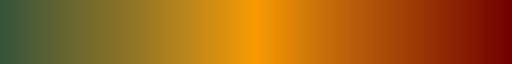

In [9]:
from matplotlib.colors import LinearSegmentedColormap
memories_cmap_colors = ["#" + s for s in ["720000","8f2704","ac4c08","ca710c","f99a03","bf881b","8e7426","656631","36543b"]]
memories_cmap = LinearSegmentedColormap.from_list("memories_cmap", memories_cmap_colors[::-1])
memories_cmap

In [10]:
def compute_right_vs_obsdiff_wmem(observations, actions, memories, M, num_bins):
    obs_diff = []
    for obs in observations:
        obs_num = np.zeros(len(obs), dtype=int)
        obs_num[obs == "left"] = -1
        obs_num[obs == "silence"] = 0
        obs_num[obs == "right"] = 1
        obs_num[obs == "end"] = 0
        obs_num[obs == "na"] = 0
        obs_diff.append(np.sum(obs_num))

    bin_edges = np.linspace(np.min(obs_diff), np.max(obs_diff) + 1, num_bins)
    num_obs_diff, _ = np.histogram(obs_diff, bins=bin_edges)

    # Histogram for number of right actions per bin
    num_R_action_curr = np.zeros(len(num_obs_diff))
    memory_occupation = np.zeros((len(num_obs_diff), M))
    bin_indices = np.digitize(obs_diff, bin_edges) - 1  # -1 for 0-indexed

    for idx_trial in range(len(actions)):
        bin_idx = bin_indices[idx_trial]
        if 0 <= bin_idx < len(num_R_action_curr):
            num_R_action_curr[bin_idx] += actions[idx_trial][-1] == "open right"
            if M >= 4:
                memory_occupation[bin_idx, int(memories[idx_trial][-3][3:])] += 1
            else:
                memory_occupation[bin_idx, int(memories[idx_trial][-3][-1])] += 1
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return bin_centers, num_R_action_curr / num_obs_diff, memory_occupation / np.sum(memory_occupation, axis=1, keepdims=True)

In [11]:
def compute_right_vs_obsdiff(observations, actions, num_bins):
    obs_diff = []
    for obs in observations:
        obs_num = np.zeros(len(obs), dtype=int)
        obs_num[obs == "left"] = -1
        obs_num[obs == "silence"] = 0
        obs_num[obs == "right"] = 1
        obs_num[obs == "end"] = 0
        obs_num[obs == "na"] = 0
        obs_diff.append(np.sum(obs_num))

    bin_edges = np.linspace(np.min(obs_diff), np.max(obs_diff) + 1, num_bins)
    num_obs_diff, _ = np.histogram(obs_diff, bins=bin_edges)

    # Histogram for number of right actions per bin
    num_R_action_curr = np.zeros(len(num_obs_diff))
    bin_indices = np.digitize(obs_diff, bin_edges) - 1  # -1 for 0-indexed

    for idx_trial in range(len(actions)):
        bin_idx = bin_indices[idx_trial]
        if 0 <= bin_idx < len(num_R_action_curr):
            num_R_action_curr[bin_idx] += actions[idx_trial][-1] == "open right"
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return bin_centers, num_R_action_curr / num_obs_diff

In [12]:
def get_obs_from_clicks(left_clicks, right_clicks, random_durations, dt):
    synth_observations = []
    NTrials = len(right_clicks)
    for idx_trial in range(NTrials):
        trj_dict = {}

        NSteps = int(np.round(random_durations[idx_trial] / dt, 0))
        timesteps = np.arange(0, NSteps) * dt

        observations_right = np.zeros(NSteps + 2)
        observations_left = np.zeros(NSteps + 2)

        for idx_click, time_click in enumerate(right_clicks[idx_trial]):
            idx_step = int(np.round(time_click / dt, 0))
            if idx_step < NSteps:
                observations_right[idx_step] += 1

        for idx_click, time_click in enumerate(left_clicks[idx_trial]):
            idx_step = int(np.round(time_click / dt, 0))
            if idx_step < NSteps:
                observations_left[idx_step] += 1
        
        obs = np.empty(NSteps + 2, dtype='<U7')
        temp_idx_obs_right = observations_right > 0
        temp_idx_obs_left = observations_left > 0
        temp_idx_obs_silence = (observations_right == 0) & (observations_left == 0)

        idx_overlapping = temp_idx_obs_right & temp_idx_obs_left

        for idx in range(len(obs)):
            if idx_overlapping[idx]:
                # if np.random.rand() > 0.5:
                #     obs[idx] = 'right'
                # else:
                #     obs[idx] = 'left'
                obs[idx] = 'silence'
            elif temp_idx_obs_right[idx]:
                obs[idx] = 'right'
            elif temp_idx_obs_left[idx]:
                obs[idx] = 'left'
            elif temp_idx_obs_silence[idx]:
                obs[idx] = 'silence'

        obs[-2] = 'end'
        obs[-1] = 'na'

        synth_observations.append(obs)

    return synth_observations

# Load data

In [13]:
dt = 1 / 40
train_percentage = 0.5

rat_names = ["T" + str(s) for s in [176, 219, 223]]

combined_rat_names = "_".join([rat_name for rat_name in rat_names])
data_path_aggregated = f"../data/RatTiger/dt{dt}/combined_trajectories/aggregated_{combined_rat_names}_train{train_percentage}/"

common_filename = "aggregation_n5"

filename_train = common_filename + f"_dt{dt}_trajectories_train.pkl"
filename_val = common_filename + f"_dt{dt}_trajectories_val.pkl"
filename_all = common_filename + f"_dt{dt}_all_trajectories.pkl"

In [14]:
with open(data_path_aggregated + filename_train, "rb") as f:
    trajectories_data_train = pickle.load(f)

with open(data_path_aggregated + filename_val, "rb") as f:
    trajectories_data_val = pickle.load(f)

with open(data_path_aggregated + filename_all, "rb") as f:
    all_trj_data = pickle.load(f)

NTrain = int(len(trajectories_data_train))
NVal = len(trajectories_data_train)

actions_data_train = [trj_data["actions"] for trj_data in trajectories_data_train]
observations_data_train = [trj_data["observations"] for trj_data in trajectories_data_train]

actions_data_val = [trj_data["actions"] for trj_data in trajectories_data_val]
observations_data_val = [trj_data["observations"] for trj_data in trajectories_data_val]

actions_data_all = actions_data_train + actions_data_val
observations_data_all = observations_data_train + observations_data_val


states_data_train = []
states_data_val = []

for i, trj_data in enumerate(all_trj_data["train"]):
    states_data = trj_data["states"][-1]
    states_data_train.append(states_data)

for i, trj_data in enumerate(all_trj_data["val"]):
    states_data = trj_data["states"][-1]
    states_data_val.append(states_data)

In [15]:
ActSpace = np.unique(np.concatenate(actions_data_train))
ObsSpace = np.unique(np.concatenate(observations_data_train))

A = len(ActSpace)
Y = len(ObsSpace)

In [16]:
idx_listen = np.where(ActSpace == "listen")[0][0]
idx_open_left = np.where(ActSpace == "open left")[0][0]
idx_open_right = np.where(ActSpace == "open right")[0][0]

idx_obs_left = np.where(ObsSpace == "left")[0][0]
idx_obs_silence = np.where(ObsSpace == "silence")[0][0]
idx_obs_right = np.where(ObsSpace == "right")[0][0]
idx_obs_end = np.where(ObsSpace == "end")[0][0]
idx_obs_na = np.where(ObsSpace == "na")[0][0]

AllowedObsFromAct = np.ones((A, Y), dtype=bool)
AllowedObsFromAct[:, idx_obs_na] = False
AllowedObsFromAct[idx_open_right, :] = False
AllowedObsFromAct[idx_open_left, :] = False

In [17]:
action_order = ["open left", "listen", "open right"]
action_to_idx = {a: i for i, a in enumerate(action_order)}

observation_order = ["left", "silence", "right", "end", "na"]
observation_to_idx = {o: i for i, o in enumerate(observation_order)}

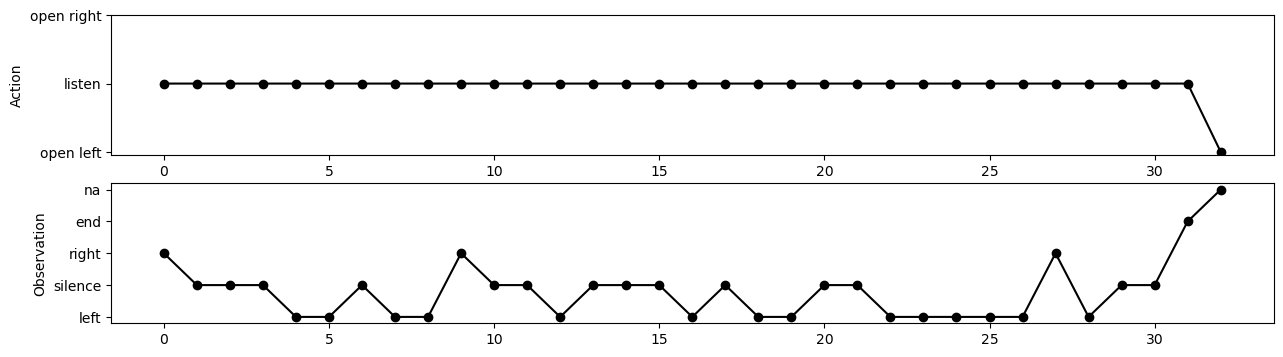

In [18]:
idx_trj = 0
fig, axs = plt.subplots(2, 1, figsize = (15, 4))

act_mapped = [action_to_idx[a] for a in trajectories_data_train[idx_trj]["actions"]]
axs[0].plot(act_mapped, '-o', c='k')
axs[0].set_ylabel("Action")
axs[0].set_yticks(range(len(action_order)))
axs[0].set_yticklabels(action_order)

obsmapped = [observation_to_idx[o] for o in trajectories_data_train[idx_trj]["observations"]]
axs[1].plot(obsmapped, '-o', c = 'k')
axs[1].set_ylabel("Observation")
axs[1].set_yticks(range(len(observation_order)))
axs[1].set_yticklabels(observation_order)
plt.show()

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_27791/2767958302.py:8: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(bins_diff_all, prob_R_all, '-o', label='All data', c = "darkred", zorder = -1, ls = '--')


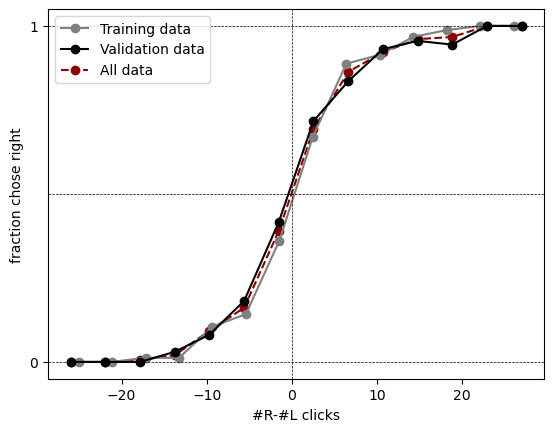

In [19]:
num_bins = 15
bins_diff_train, prob_R_train = compute_right_vs_obsdiff(observations_data_train, actions_data_train, num_bins)
bins_diff_val, prob_R_val = compute_right_vs_obsdiff(observations_data_val, actions_data_val, num_bins)
bins_diff_all, prob_R_all = compute_right_vs_obsdiff(observations_data_all, actions_data_all, num_bins)

plt.plot(bins_diff_train, prob_R_train, '-o', label='Training data', c = "gray")
plt.plot(bins_diff_val, prob_R_val, '-o', label='Validation data', c = "k")
plt.plot(bins_diff_all, prob_R_all, '-o', label='All data', c = "darkred", zorder = -1, ls = '--')
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.5)
plt.axvline(0, color='k', linestyle='--', linewidth=0.5)
plt.xlabel('#R-#L clicks')
plt.ylabel('fraction chose right')
#plt.xlim([-40, 40])
plt.ylim([-0.05, 1.05])
plt.yticks([0, 1])
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
plt.axhline(1, color='k', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Load trained FSCs

In [20]:
path_FSC = data_path_aggregated + f"FSC_params_complayer_fixedrho_{common_filename}/"

In [34]:
M_array = np.arange(2, 8, 1)

files_in_path = os.listdir(path_FSC)
FSC_params = [f for f in files_in_path if f.startswith("FSC") ]

FSC_list_M = []
MemSpaces_list = []
best_restart_idxs = []
best_restart_idxs_train = []

for M in M_array:
    tic = measure_time.time()

    if M < 4:
        MemSpace = np.array(["M-" + str(num) for num in range(M)])
    else:
        MemSpace_l1 = np.array(["M1-" + str(num) for num in range(M - 2)])
        MemSpace_l2 = np.array(["M2-" + str(num) for num in range(M - 2, M)])
        MemSpace = np.concatenate([MemSpace_l1, MemSpace_l2])

    MemSpaces_list.append(MemSpace)

    FSC_temp_list = []
    train_losses_list = []
    
    print("Loading FSC with M =", M)
    FSC_params_M = [f for f in FSC_params if f"M{M}_" in f]

    for filename in FSC_params_M:
        with open(os.path.join(path_FSC, filename), "rb") as f:
            print("\t Loading", filename)
            FSC_params_curr = pickle.load(f)

            FSC_curr = controller.FSC(M = M, A = A, Y = Y,
                                      mode = "generation",
                                      policy_model = "softmax",
                                      policy_params = {"theta": FSC_params_curr["theta"], "zeta": FSC_params_curr["zeta"]},
                                      psi = FSC_params_curr["psi"],
                                      ActSpace = ActSpace, MemSpace = MemSpace,
                                      ObsSpace = ObsSpace)
            
            FSC_curr.best_loss = FSC_curr.compute_loss(trajectories_data_val)
            curr_train_loss = FSC_params_curr["training_loss"]
            if len(curr_train_loss) < 1500:
                curr_train_loss = np.concatenate([FSC_params_curr["training_loss"],
                                                 [curr_train_loss[-1]] * (1500 - len(curr_train_loss))])
            FSC_curr.losses_epochs = {"train": curr_train_loss}
            train_losses_list.append(curr_train_loss[-1])
                
            print("\t Recomputed loss on validation data:", FSC_curr.best_loss)

        if type(FSC_curr) is list:
            for FSC in FSC_curr:
                FSC_temp_list.append(FSC)
        else:
            FSC_temp_list.append(FSC_curr)

    best_restart_idx = np.argmin([FSC.best_loss for FSC in FSC_temp_list])
    best_restart_idxs.append(best_restart_idx)

    best_restart_idx_train = np.argmin(train_losses_list)
    best_restart_idxs_train.append(best_restart_idx_train)

    FSC_list_M.append(FSC_temp_list)
    toc = measure_time.time()

    print("FSC with M =", M, "completed in", round(toc - tic, 2), "seconds.")
    print("Best validation loss:", FSC_temp_list[best_restart_idx].best_loss)
    print("Best training loss:", train_losses_list[best_restart_idx_train])
    print("\n")

Loading FSC with M = 2
	 Loading FSC_discrete_params_M2_A3_Y5_trained_loss0.692722_aggregation_n5_restart1.pkl
	 Recomputed loss on validation data: 0.6935720201358747
FSC with M = 2 completed in 0.18 seconds.
Best validation loss: 0.6935720201358747
Best training loss: 0.6927224601224843


Loading FSC with M = 3
	 Loading FSC_discrete_params_M3_A3_Y5_trained_loss0.692722_aggregation_n5_restart8.pkl
	 Recomputed loss on validation data: 0.6935720201356256
	 Loading FSC_discrete_params_M3_A3_Y5_trained_loss0.692722_aggregation_n5_restart9.pkl
	 Recomputed loss on validation data: 0.6935720202921516
	 Loading FSC_discrete_params_M3_A3_Y5_trained_loss0.692722_aggregation_n5_restart10.pkl
	 Recomputed loss on validation data: 0.69357202187295
	 Loading FSC_discrete_params_M3_A3_Y5_trained_loss0.692722_aggregation_n5_restart5.pkl
	 Recomputed loss on validation data: 0.6935720201358747
	 Loading FSC_discrete_params_M3_A3_Y5_trained_loss0.692722_aggregation_n5_restart7.pkl
	 Recomputed loss 

There are 1 FSCs with M = 2
There are 5 FSCs with M = 3
There are 2 FSCs with M = 4
There are 5 FSCs with M = 5
There are 5 FSCs with M = 6
There are 5 FSCs with M = 7


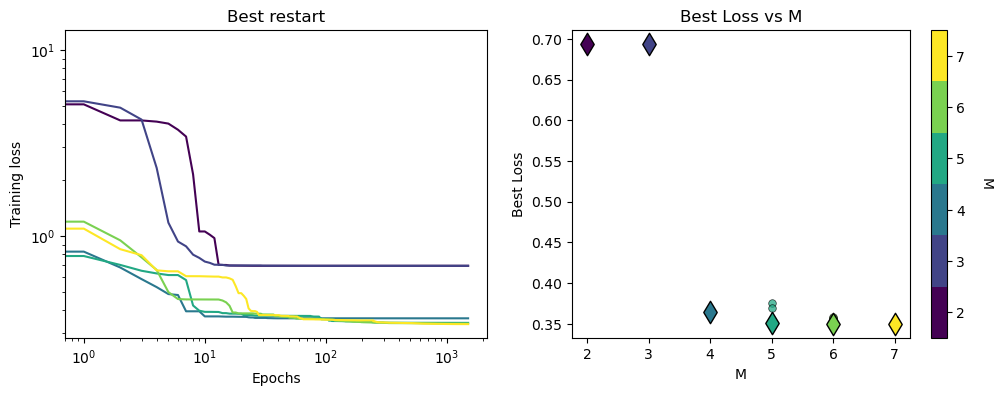

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Training loss')
axs[0].set_title('Best restart')
axs[1].set_xlabel('M')
axs[1].set_ylabel('Best Loss')
axs[1].set_title('Best Loss vs M')
axs[0].set_yscale('log')
colors = plt.get_cmap("viridis")(np.linspace(0, 1, len(FSC_list_M)))

for idx, FSC_list in enumerate(FSC_list_M):
    print("There are", len(FSC_list), "FSCs with M =", M_array[idx])
    FSC_curr_best = FSC_list[best_restart_idxs[idx]]
    axs[0].plot(FSC_curr_best.losses_epochs["train"], label="M = " + str(FSC_curr_best.M), color=colors[idx])

    for i in range(len(FSC_list)):
        FSC_curr = FSC_list[i]
        axs[1].scatter(FSC_curr.M, FSC_curr.best_loss, color=colors[idx], s=30, edgecolor='k', lw = 0.5, alpha=0.75)

    axs[1].scatter(FSC_curr_best.M, FSC_curr_best.best_loss, color=colors[idx],
                   marker='d',
                   s=130, edgecolor='k', lw = 1., label="Best M = " + str(FSC_curr_best.M))

cmap = plt.get_cmap("viridis", len(FSC_list_M))
norm = BoundaryNorm(np.arange(len(FSC_list_M)+1)-0.5, len(FSC_list_M))

# Create a ScalarMappable and colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=axs[1], orientation='vertical', ticks=np.arange(len(FSC_list_M)))
cbar.set_label('M', rotation=270, labelpad=20)
cbar.set_ticks(np.arange(len(FSC_list_M)))
cbar.set_ticklabels(M_array)
cbar.ax.yaxis.set_minor_locator(plt.NullLocator())

plt.show()

In [36]:
best_losses_M_list = []
best_FSC_M_list = []
for idx, FSC_list in enumerate(FSC_list_M):
    FSC_curr_best = FSC_list[best_restart_idxs[idx]]
    best_losses_M_list.append(FSC_curr_best.best_loss)
    best_FSC_M_list.append(FSC_curr_best)
    print("Best validation loss for M = ", FSC_curr_best.M, " is ", FSC_curr_best.best_loss)
print("")

Best validation loss for M =  2  is  0.6935720201358747
Best validation loss for M =  3  is  0.6935720201356256
Best validation loss for M =  4  is  0.36433483200632205
Best validation loss for M =  5  is  0.3508233751497553
Best validation loss for M =  6  is  0.34963869050952506
Best validation loss for M =  7  is  0.349701623127503



In [37]:
best_train_losses_M_list = []
best_train_FSC_M_list = []
for idx, FSC_list in enumerate(FSC_list_M):
    FSC_curr_best = FSC_list[best_restart_idxs_train[idx]]
    best_train_losses_M_list.append(FSC_curr_best.compute_loss(trajectories_data_train))
    best_train_FSC_M_list.append(FSC_curr_best)
    print("Best training loss for M = ", FSC_curr_best.M, " is ", best_train_losses_M_list[-1])

print("")

Best training loss for M =  2  is  0.6927224601225433
Best training loss for M =  3  is  0.6927224601225433
Best training loss for M =  4  is  0.3616723437030198
Best training loss for M =  5  is  0.34184925190088095
Best training loss for M =  6  is  0.33889270169350133
Best training loss for M =  7  is  0.33662688164101917



In [38]:
all_losses_epochs_train = []
for idx, FSC_list in enumerate(FSC_list_M):
    FSC_curr_best = FSC_list[best_restart_idxs[idx]]
    all_losses_epochs_train.append(FSC_curr_best.losses_epochs["train"])

In [39]:
all_losses = []

for idx_M, FSC_list in enumerate(FSC_list_M):
    curr_losses = np.zeros(len(FSC_list))
    for idx_restart, FSC in enumerate(FSC_list):
        curr_losses[idx_restart] = FSC.best_loss
        
    all_losses.append(curr_losses)

# Analysis for the best FSC with M = 2

In [335]:
idx_best_M2 = 0
FSC_M2 = best_FSC_M_list[idx_best_M2]
MemSpace_best = MemSpaces_list[idx_best_M2]

print("Best loss for M =", FSC_M2.M, "is", FSC_M2.best_loss)

FSC_M2.set_mode("generation")

generated_trajectories_train = []
for obs_seq in observations_data_train:
    trj = FSC_M2.generate_trajectories(obs_from_act = True,
                                   NTraj = 10,
                                   observations = obs_seq)
    generated_trajectories_train.append(trj)

generated_trajectories_val = []
for obs_seq in observations_data_val:
    trj = FSC_M2.generate_trajectories(obs_from_act = True,
                                   NTraj = 10,
                                   observations = obs_seq)
    generated_trajectories_val.append(trj)

generated_trajectories_all = generated_trajectories_train + generated_trajectories_val

Best loss for M = 2 is 0.6935720201358747


In [337]:
idx_trj_tr = 0
idx_trj_tr_rep = 0
idx_trj_val = 0
idx_trj_val_rep = 0

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_3604/883930890.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


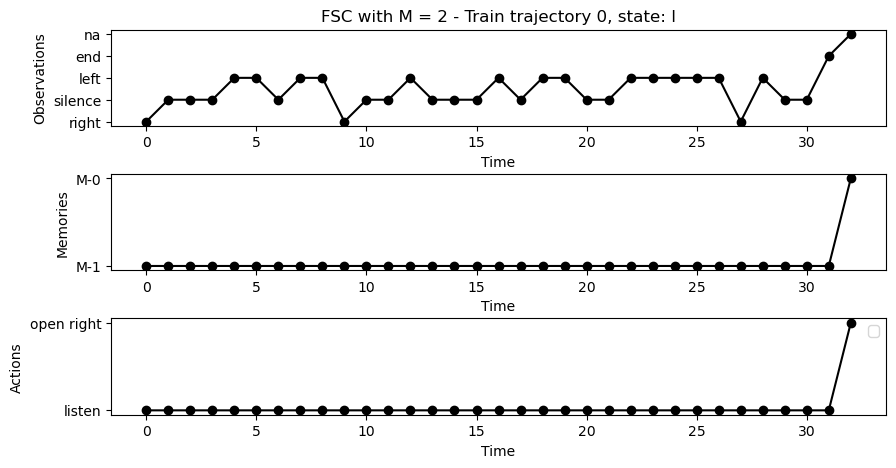

In [338]:
trj = generated_trajectories_train[idx_trj_tr][idx_trj_tr_rep]
fig, ax = FSC_M2.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M2.M) + ' - Train trajectory ' + str(idx_trj_tr) + ", state: " + states_data_train[idx_trj_tr])
ax[2].legend(handlelength = 0.5)
plt.show()

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_3604/730725905.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


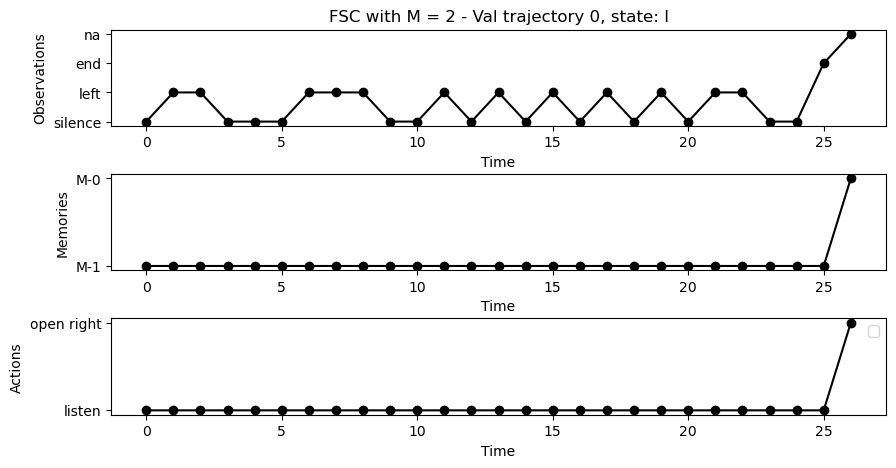

In [339]:
trj = generated_trajectories_val[idx_trj_val][idx_trj_val_rep]
fig, ax = FSC_M2.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M2.M) + ' - Val trajectory ' + str(idx_trj_val) + ", state: " + states_data_val[idx_trj_val])
ax[2].legend(handlelength = 0.5)
plt.show()

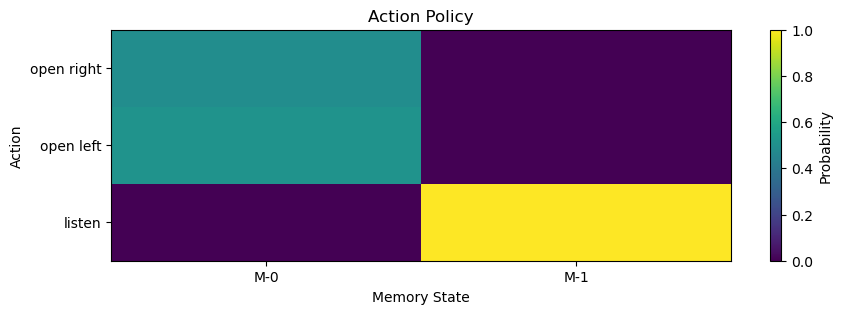

In [340]:
fig, ax = plt.subplots(figsize=(10, 3))
c = ax.pcolormesh(MemSpace_best, ActSpace, FSC_M2.get_action_policy().T)
ax.set_xlabel('Memory State')
ax.set_ylabel('Action')
ax.set_title('Action Policy')
fig.colorbar(c, ax=ax, label='Probability', orientation='vertical')
plt.show()

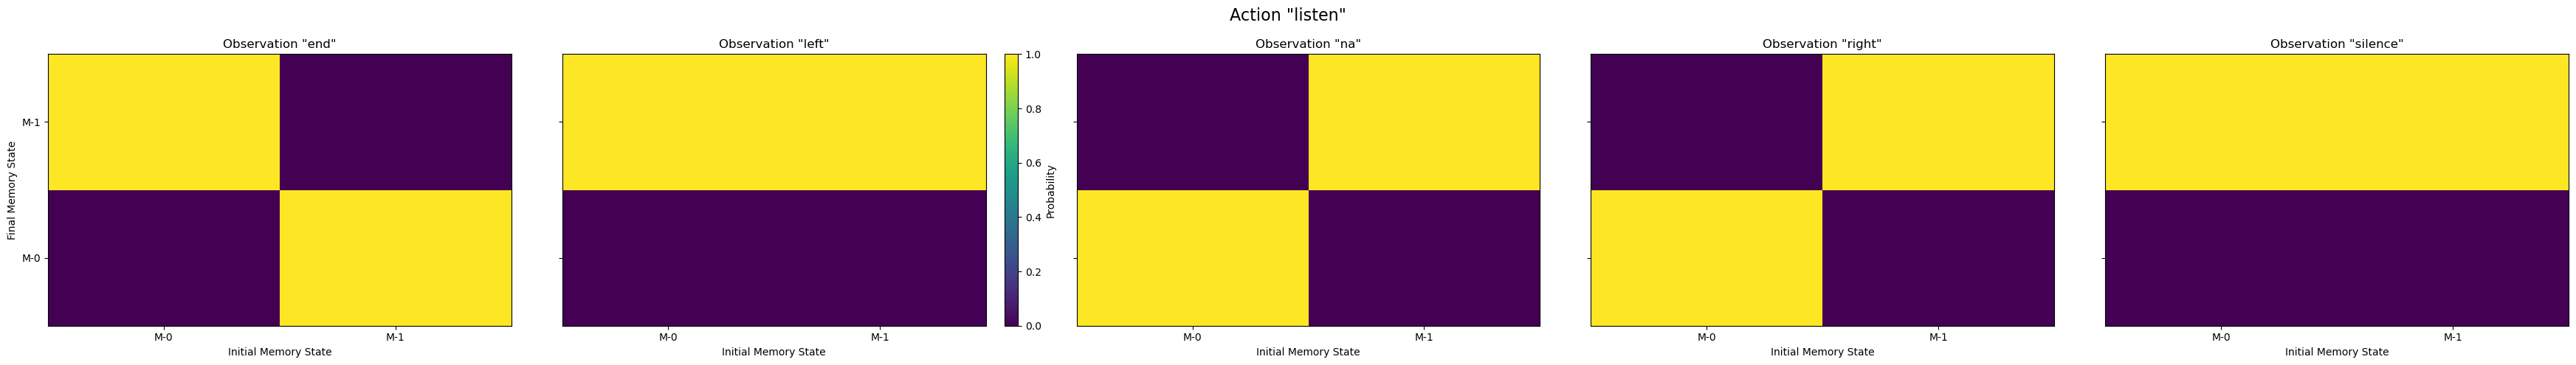

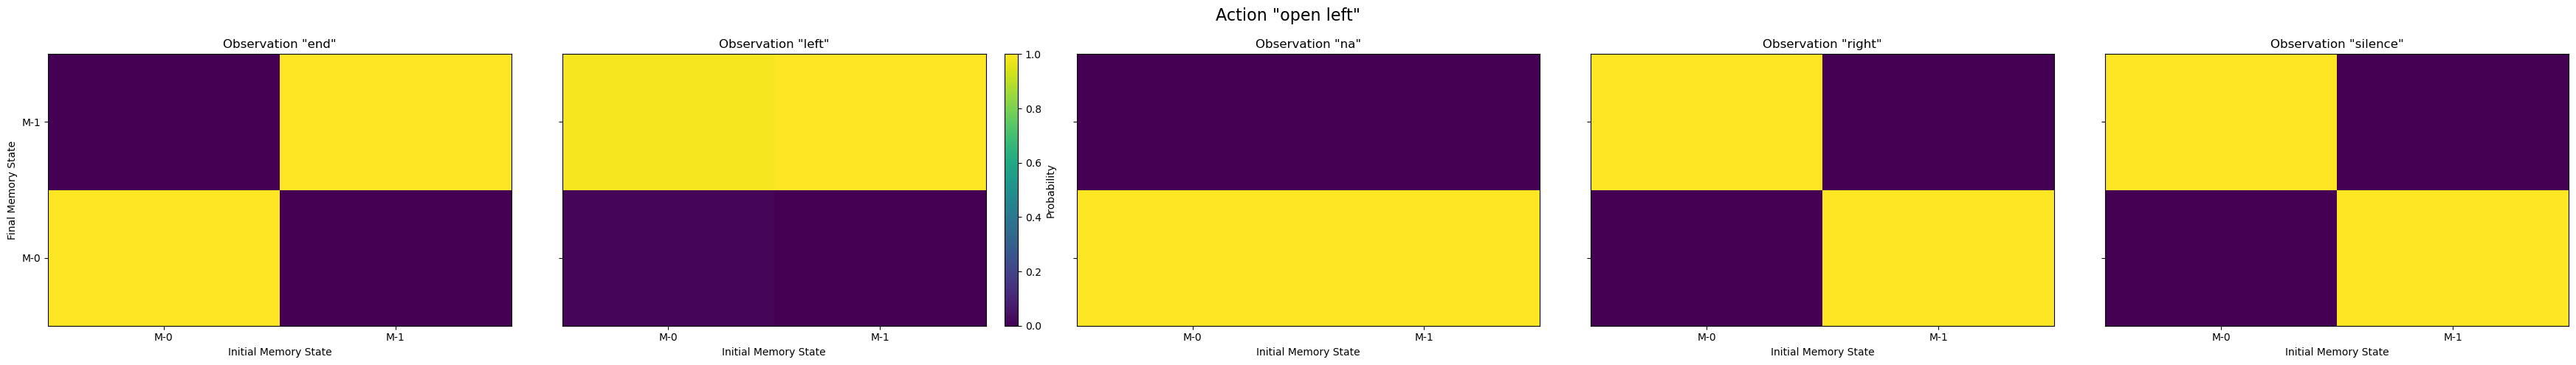

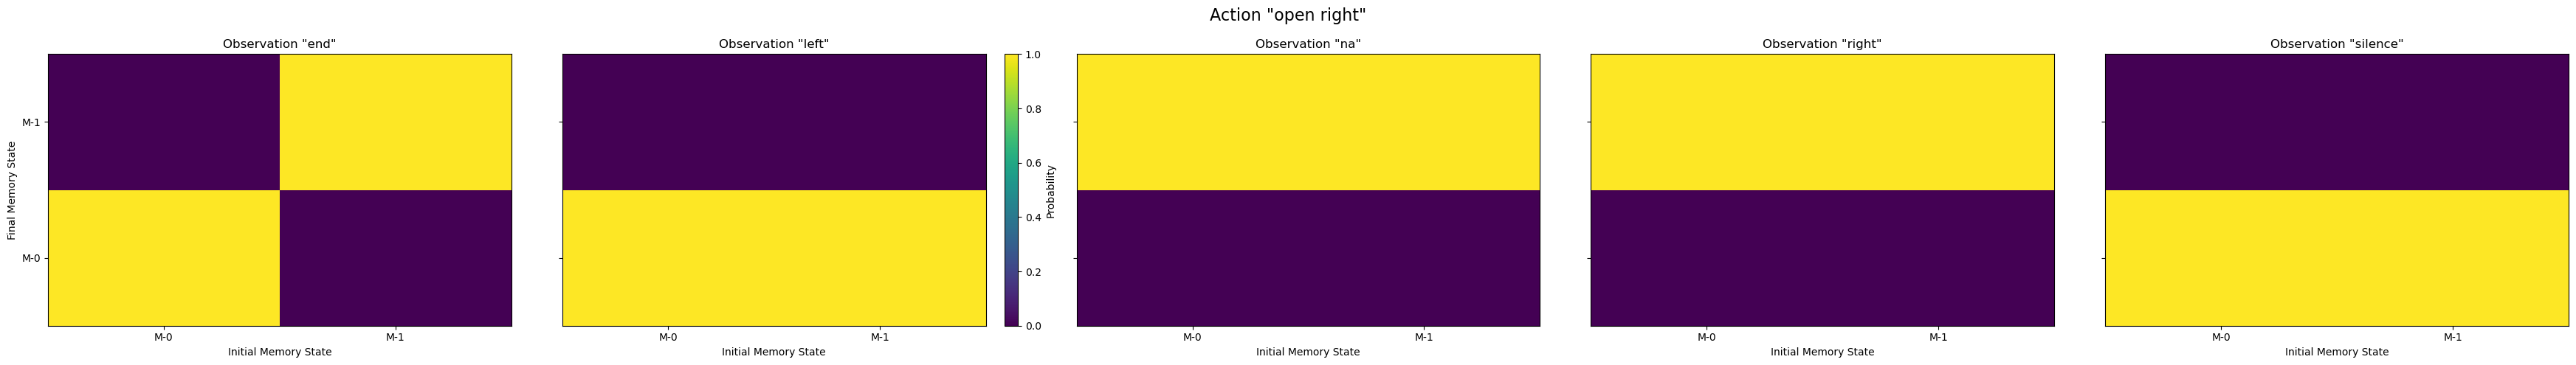

In [341]:
for idx_act in range(len(ActSpace)):
    fig, axs = plt.subplots(1, len(ObsSpace), figsize=(35, 5), sharey=True)
    for idx_obs in range(len(ObsSpace)):
        c = axs[idx_obs].pcolormesh(
            MemSpace_best,
            MemSpace_best,
            FSC_M2.get_memory_transitions()[idx_obs][idx_act].T
        )
        axs[idx_obs].set_xlabel('Initial Memory State')
        axs[idx_obs].set_title(f'Observation "{ObsSpace[idx_obs]}"')
        fig.suptitle(f'Action "{ActSpace[idx_act]}"', fontsize=16)
        if idx_obs == 0:
            axs[idx_obs].set_ylabel('Final Memory State')
        if idx_obs == 1:
            fig.colorbar(c, ax=axs[idx_obs], label='Probability', orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

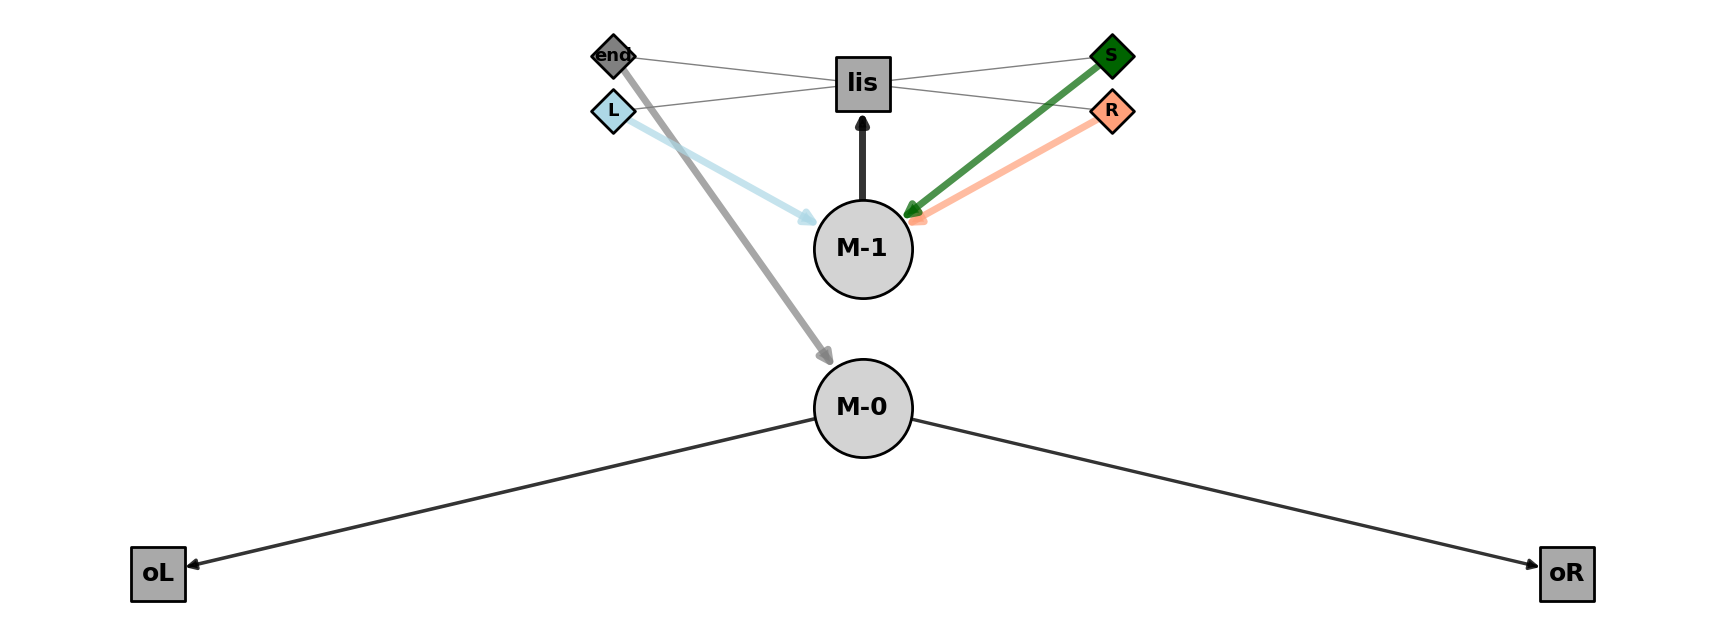

In [354]:
chain_ordering = [1, 0]

fig, ax = plt.subplots(figsize=(22, 8))
FSC_M2.plot_bipartite_FSC(observation_node_colors=["gray", 'lightblue', "k", 'lightsalmon', "darkgreen"],
                               memory_ordering = chain_ordering,
                               memory_names=MemSpace_best[chain_ordering],
                               action_names=['lis', 'oL', 'oR'], observation_names=["end", 'L', "", 'R', "S"],
                               AllowedObsFromAct = AllowedObsFromAct, obs_rotation=np.pi/4 * 3,
                               ax = ax)
plt.show()

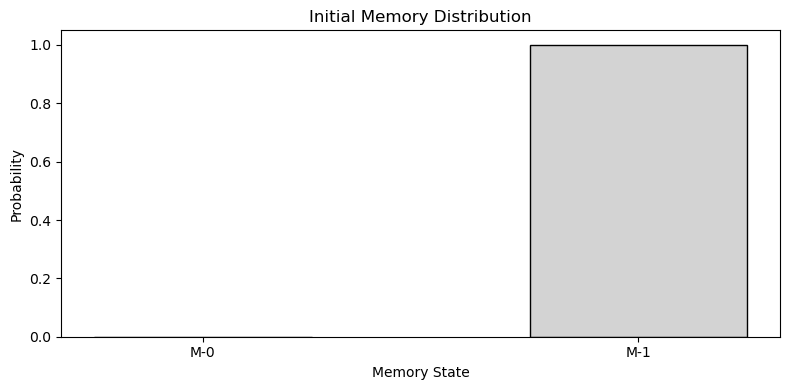

In [356]:
rho = FSC_M2.rho

# rho is the initial distribution of memory states, make an histogram of it
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(rho)), rho, color='lightgray', edgecolor='k', width=0.5)
ax.set_xlabel('Memory State')
ax.set_ylabel('Probability')
ax.set_title('Initial Memory Distribution')
ax.set_xticks(np.arange(len(MemSpace_best)), MemSpace_best)
plt.tight_layout()
plt.show()

In [357]:
generated_observations_train = []
generated_actions_train = []
generated_memories_train = []
for trjseq in generated_trajectories_train:
    for trj in trjseq:
        generated_observations_train.append(trj["observations"])
        generated_actions_train.append(trj["actions"])
        generated_memories_train.append(trj["memories"])

generated_observations_val = []
generated_actions_val = []
generated_memories_val = []
for trjseq in generated_trajectories_val:
    for trj in trjseq:
        generated_observations_val.append(trj["observations"])
        generated_actions_val.append(trj["actions"])
        generated_memories_val.append(trj["memories"])

In [358]:
num_bins = 20
bins_diff_train_gen, prob_R_train_gen, mem_occ_train_gen = compute_right_vs_obsdiff_wmem(generated_observations_train,
                                                                                         generated_actions_train,
                                                                                         generated_memories_train,
                                                                                         FSC_M2.M,
                                                                                         num_bins)
bins_diff_val_gen, prob_R_val_gen, mem_occ_val_gen = compute_right_vs_obsdiff_wmem(generated_observations_val,
                                                                                   generated_actions_val,
                                                                                   generated_memories_val,
                                                                                   FSC_M2.M,
                                                                                   num_bins)

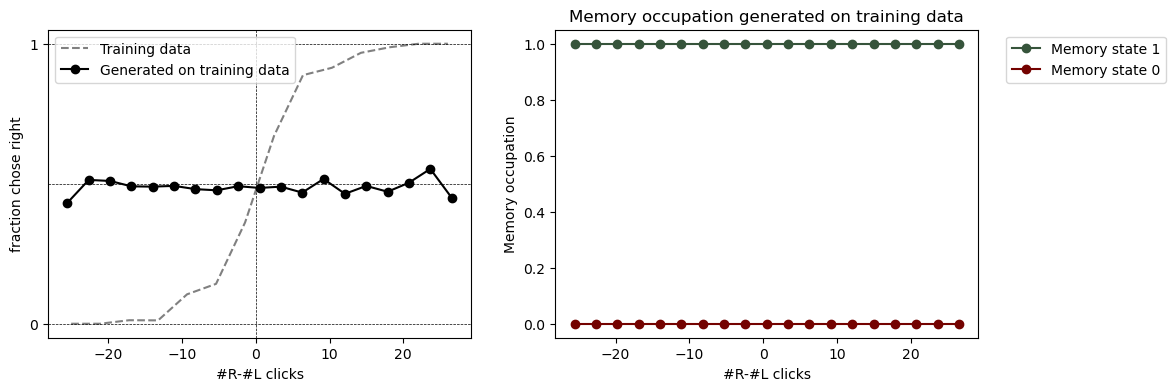

In [359]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_train, prob_R_train, ls = '--', label='Training data', c = "gray")
axs[0].plot(bins_diff_train_gen, prob_R_train_gen, '-o', label='Generated on training data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M2.M]):
    color_mem = memories_cmap(idx_seq * 0.99)
    axs[1].plot(bins_diff_train_gen, mem_occ_train_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)
    
axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on training data')
plt.show()

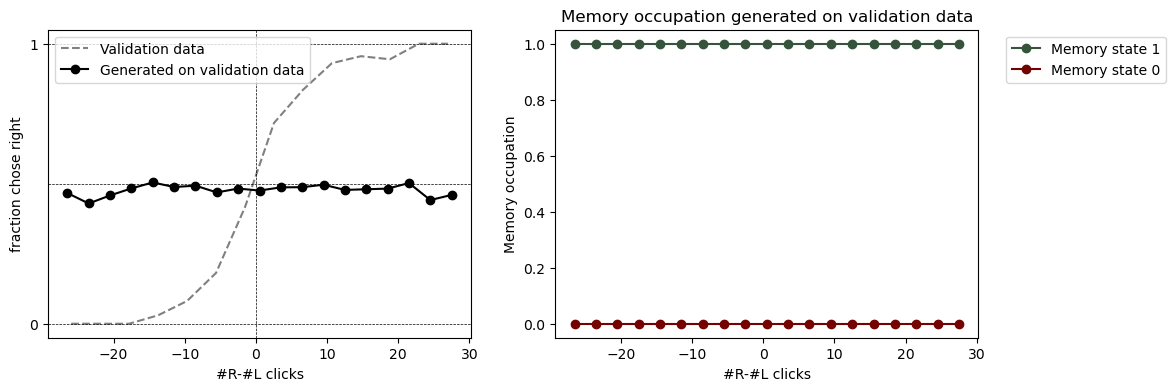

In [360]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_val, prob_R_val, ls = '--', label='Validation data', c = "gray")
axs[0].plot(bins_diff_val_gen, prob_R_val_gen, '-o', label='Generated on validation data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M2.M]):
    color_mem = memories_cmap(idx_seq * 0.99)
    axs[1].plot(bins_diff_val_gen, mem_occ_val_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)

axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on validation data')
plt.show()

# Analysis for the best FSC with M = 3

In [361]:
idx_best_M3 = 1
FSC_M3 = best_FSC_M_list[idx_best_M3]
MemSpace_best = MemSpaces_list[idx_best_M3]

print("Best loss for M =", FSC_M3.M, "is", FSC_M3.best_loss)

FSC_M3.set_mode("generation")

generated_trajectories_train = []
for obs_seq in observations_data_train:
    trj = FSC_M3.generate_trajectories(obs_from_act = True,
                                   NTraj = 10,
                                   observations = obs_seq)
    generated_trajectories_train.append(trj)

generated_trajectories_val = []
for obs_seq in observations_data_val:
    trj = FSC_M3.generate_trajectories(obs_from_act = True,
                                   NTraj = 10,
                                   observations = obs_seq)
    generated_trajectories_val.append(trj)

generated_trajectories_all = generated_trajectories_train + generated_trajectories_val

Best loss for M = 3 is 0.693572016661772


In [363]:
idx_trj_tr = 0
idx_trj_tr_rep = 0
idx_trj_val = 0
idx_trj_val_rep = 0

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_3604/3295191558.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


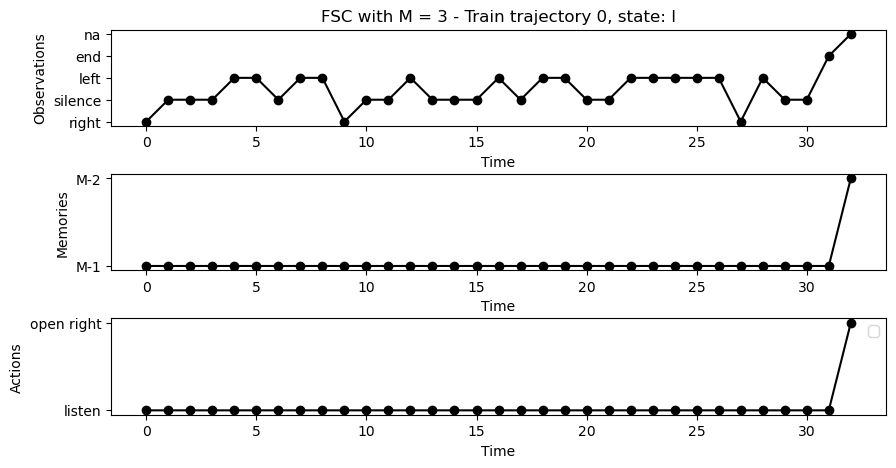

In [364]:
trj = generated_trajectories_train[idx_trj_tr][idx_trj_tr_rep]
fig, ax = FSC_M3.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M3.M) + ' - Train trajectory ' + str(idx_trj_tr) + ", state: " + states_data_train[idx_trj_tr])
ax[2].legend(handlelength = 0.5)
plt.show()

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_3604/915627588.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


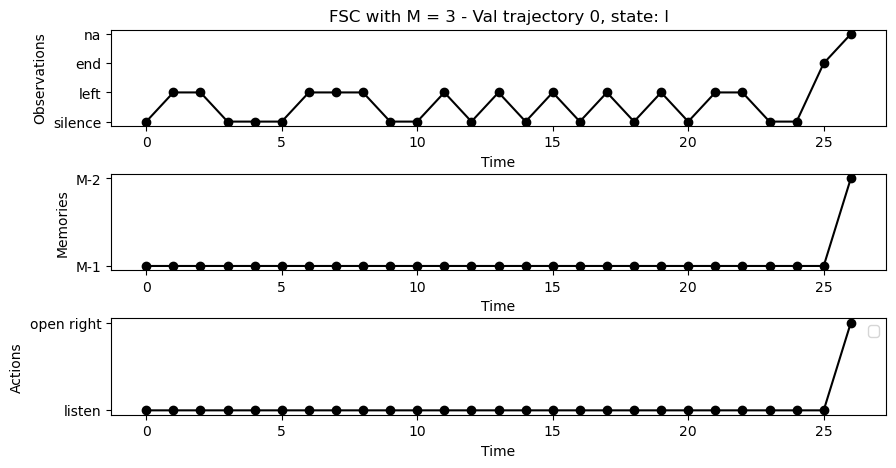

In [365]:
trj = generated_trajectories_val[idx_trj_val][idx_trj_val_rep]
fig, ax = FSC_M3.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M3.M) + ' - Val trajectory ' + str(idx_trj_val) + ", state: " + states_data_val[idx_trj_val])
ax[2].legend(handlelength = 0.5)
plt.show()

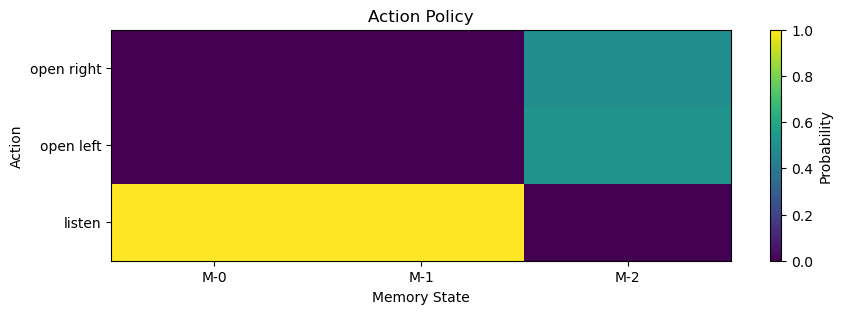

In [366]:
fig, ax = plt.subplots(figsize=(10, 3))
c = ax.pcolormesh(MemSpace_best, ActSpace, FSC_M3.get_action_policy().T)
ax.set_xlabel('Memory State')
ax.set_ylabel('Action')
ax.set_title('Action Policy')
fig.colorbar(c, ax=ax, label='Probability', orientation='vertical')
plt.show()

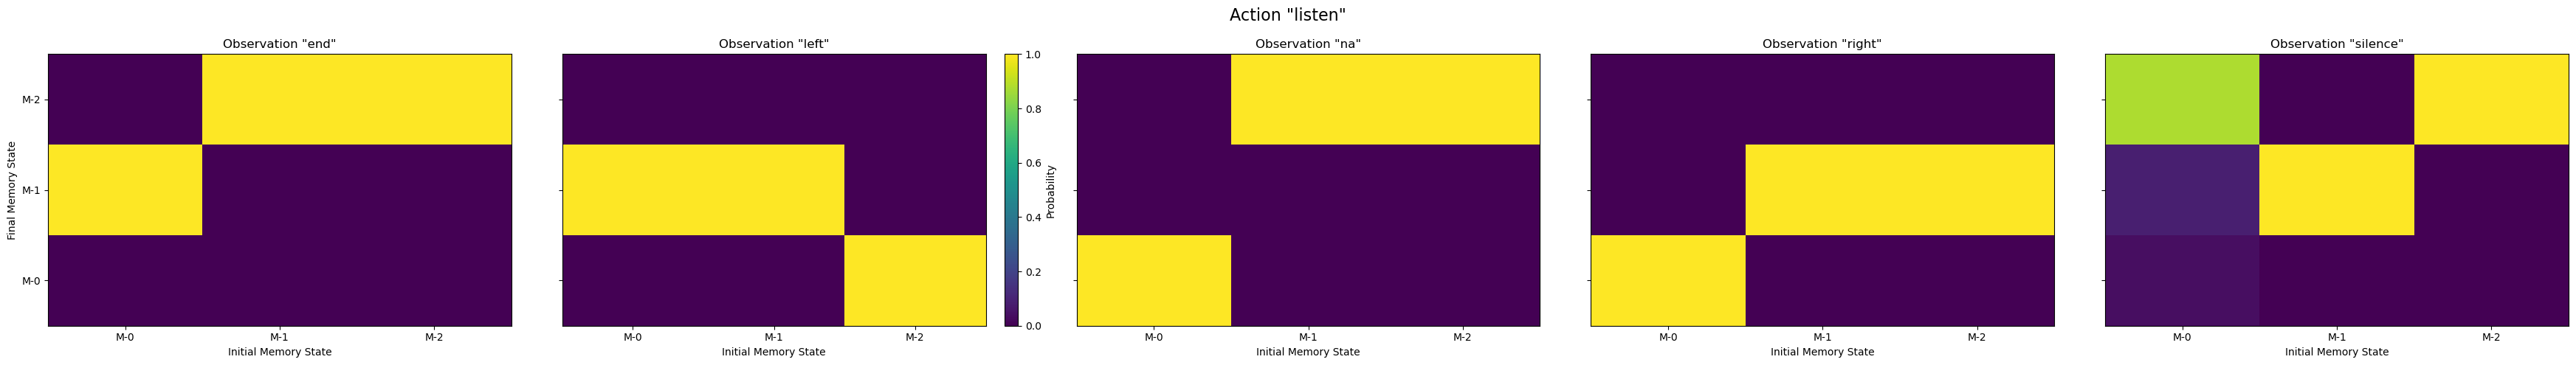

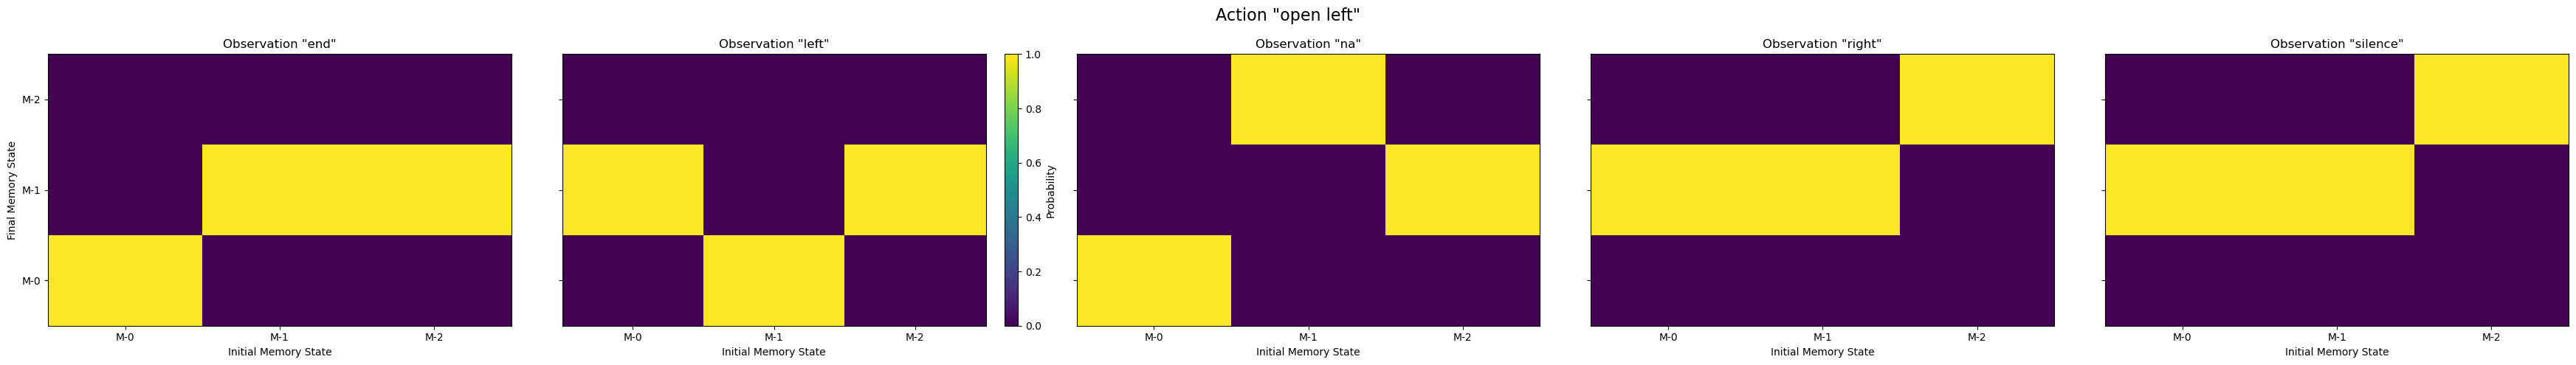

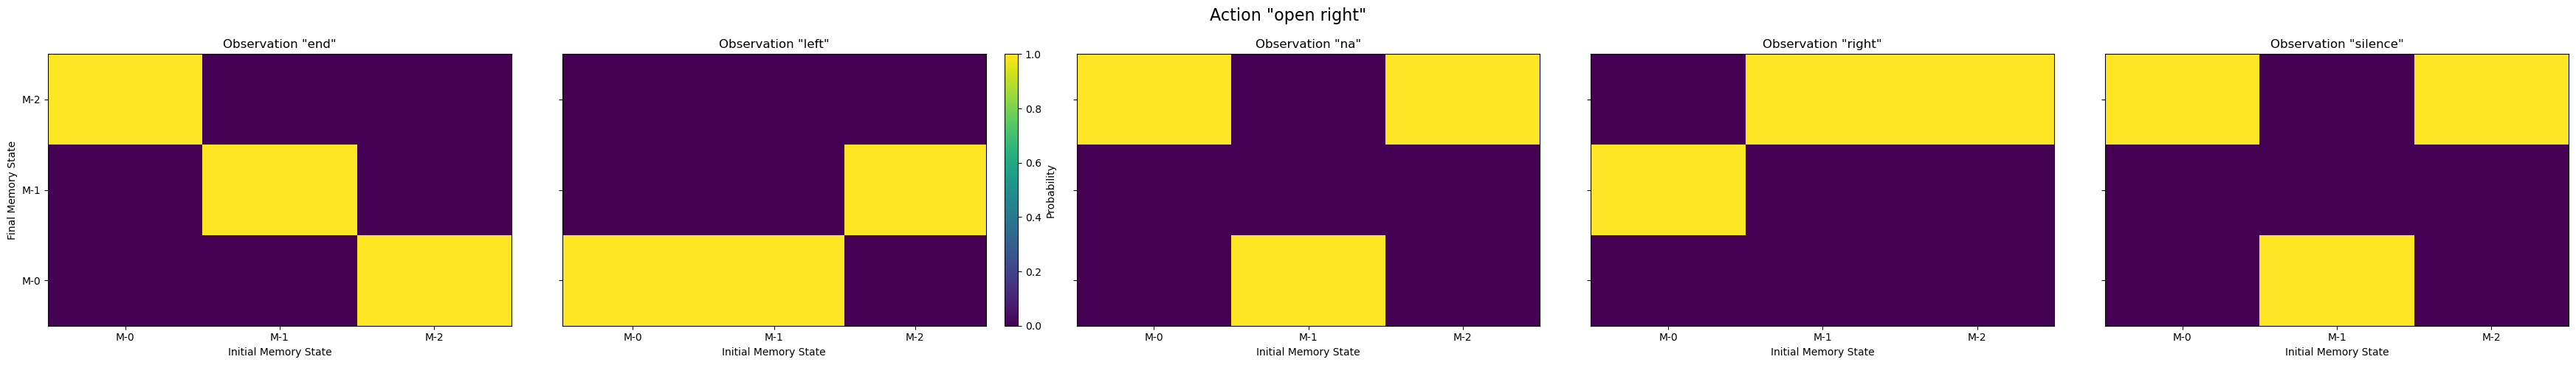

In [367]:
for idx_act in range(len(ActSpace)):
    fig, axs = plt.subplots(1, len(ObsSpace), figsize=(35, 5), sharey=True)
    for idx_obs in range(len(ObsSpace)):
        c = axs[idx_obs].pcolormesh(
            MemSpace_best,
            MemSpace_best,
            FSC_M3.get_memory_transitions()[idx_obs][idx_act].T
        )
        axs[idx_obs].set_xlabel('Initial Memory State')
        axs[idx_obs].set_title(f'Observation "{ObsSpace[idx_obs]}"')
        fig.suptitle(f'Action "{ActSpace[idx_act]}"', fontsize=16)
        if idx_obs == 0:
            axs[idx_obs].set_ylabel('Final Memory State')
        if idx_obs == 1:
            fig.colorbar(c, ax=axs[idx_obs], label='Probability', orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

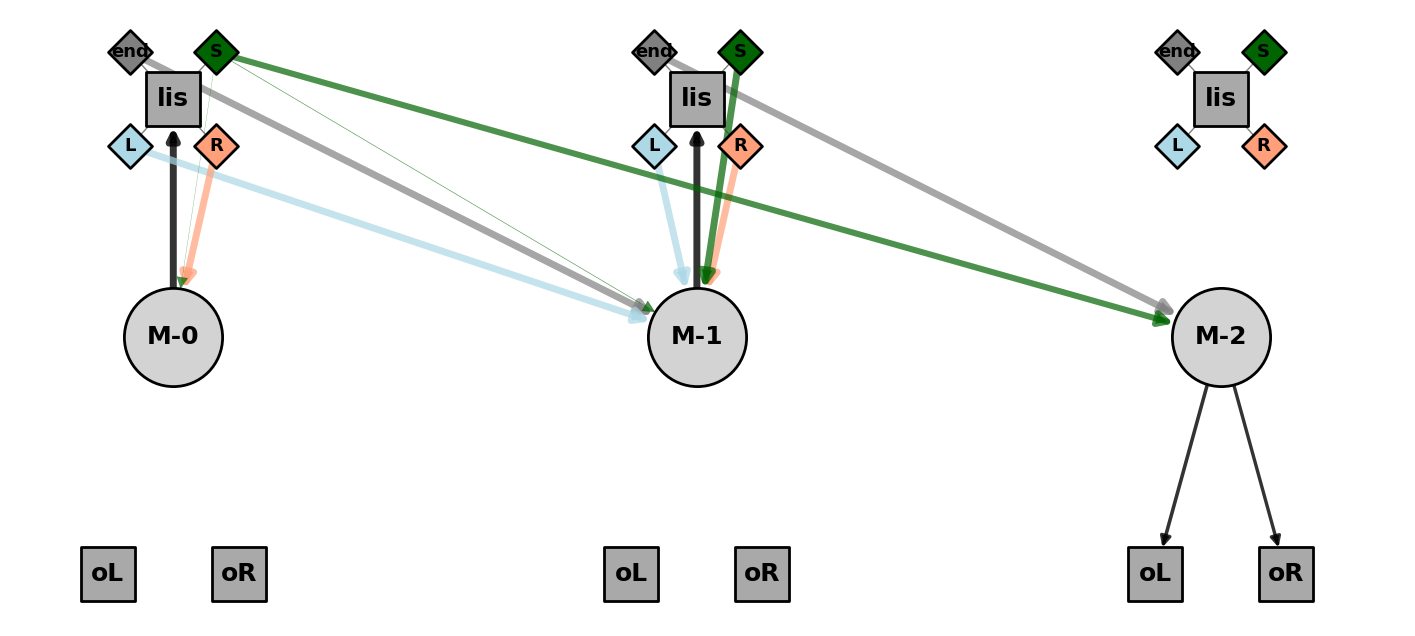

In [369]:
chain_ordering = [0, 1, 2]
ax = FSC_M3.plot_FSC(observation_node_colors=["gray", 'lightblue', "k", 'lightsalmon', "darkgreen"],
                        memory_ordering = chain_ordering,
                        memory_names=MemSpace_best[chain_ordering],
                        action_names=['lis', 'oL', 'oR'], observation_names=["end", 'L', "", 'R', "S"],
                        AllowedObsFromAct = AllowedObsFromAct, obs_rotation=np.pi/4 * 3,
                        fade_no_incoming = False
                        )

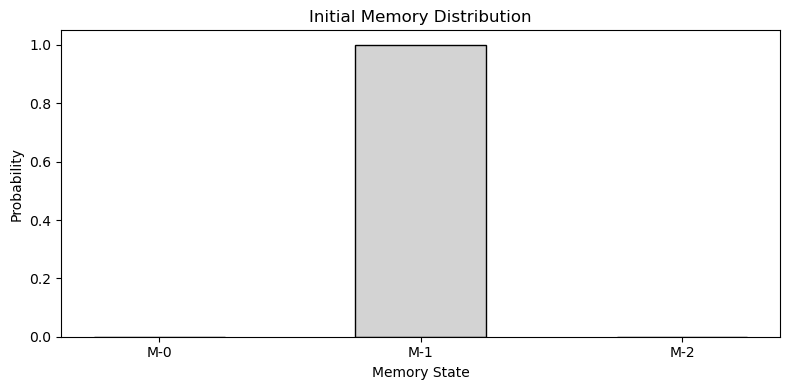

In [371]:
rho = FSC_M3.rho

# rho is the initial distribution of memory states, make an histogram of it
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(rho)), rho, color='lightgray', edgecolor='k', width=0.5)
ax.set_xlabel('Memory State')
ax.set_ylabel('Probability')
ax.set_title('Initial Memory Distribution')
ax.set_xticks(np.arange(len(MemSpace_best)), MemSpace_best)
plt.tight_layout()
plt.show()

In [372]:
generated_observations_train = []
generated_actions_train = []
generated_memories_train = []
for trjseq in generated_trajectories_train:
    for trj in trjseq:
        generated_observations_train.append(trj["observations"])
        generated_actions_train.append(trj["actions"])
        generated_memories_train.append(trj["memories"])

generated_observations_val = []
generated_actions_val = []
generated_memories_val = []
for trjseq in generated_trajectories_val:
    for trj in trjseq:
        generated_observations_val.append(trj["observations"])
        generated_actions_val.append(trj["actions"])
        generated_memories_val.append(trj["memories"])

In [373]:
num_bins = 20
bins_diff_train_gen, prob_R_train_gen, mem_occ_train_gen = compute_right_vs_obsdiff_wmem(generated_observations_train,
                                                                                         generated_actions_train,
                                                                                         generated_memories_train,
                                                                                         FSC_M3.M,
                                                                                         num_bins)
bins_diff_val_gen, prob_R_val_gen, mem_occ_val_gen = compute_right_vs_obsdiff_wmem(generated_observations_val,
                                                                                   generated_actions_val,
                                                                                   generated_memories_val,
                                                                                   FSC_M3.M,
                                                                                   num_bins)

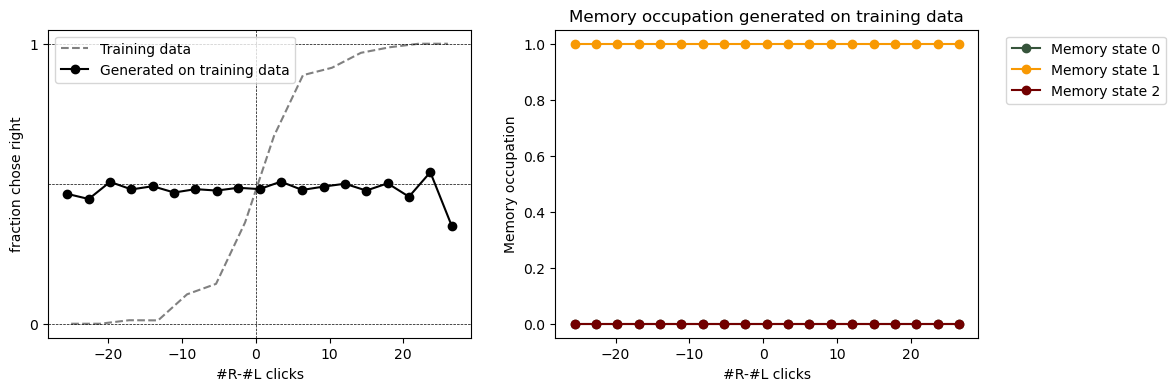

In [374]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_train, prob_R_train, ls = '--', label='Training data', c = "gray")
axs[0].plot(bins_diff_train_gen, prob_R_train_gen, '-o', label='Generated on training data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M3.M]):
    color_mem = memories_cmap(idx_seq / (FSC_M3.M - 1))
    axs[1].plot(bins_diff_train_gen, mem_occ_train_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)
    
axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on training data')
plt.show()

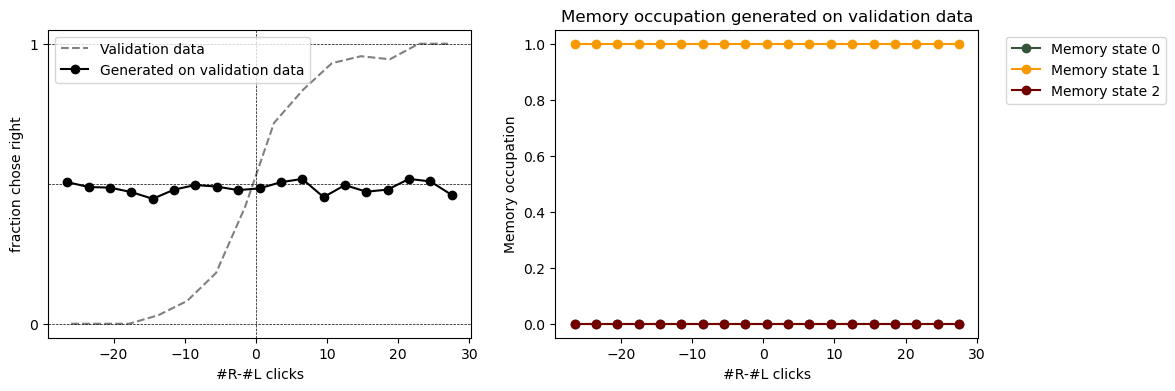

In [375]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_val, prob_R_val, ls = '--', label='Validation data', c = "gray")
axs[0].plot(bins_diff_val_gen, prob_R_val_gen, '-o', label='Generated on validation data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M3.M]):
    color_mem = memories_cmap(idx_seq / (FSC_M3.M - 1))
    axs[1].plot(bins_diff_val_gen, mem_occ_val_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)

axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on validation data')
plt.show()

# Analysis for the best FSC with M = 4

In [28]:
idx_best_M4 = 2
FSC_M4 = best_FSC_M_list[idx_best_M4]
MemSpace_best = MemSpaces_list[idx_best_M4]

print("Best loss for M =", FSC_M4.M, "is", FSC_M4.best_loss)

FSC_M4.set_mode("generation")

generated_trajectories_train = []
for obs_seq in observations_data_train:
    trj = FSC_M4.generate_trajectories(obs_from_act = True,
                                   NTraj = 10,
                                   observations = obs_seq)
    generated_trajectories_train.append(trj)

generated_trajectories_val = []
for obs_seq in observations_data_val:
    trj = FSC_M4.generate_trajectories(obs_from_act = True,
                                   NTraj = 10,
                                   observations = obs_seq)
    generated_trajectories_val.append(trj)

generated_trajectories_all = generated_trajectories_train + generated_trajectories_val

Best loss for M = 4 is 0.36433483200632205


In [30]:
idx_trj_tr = 0
idx_trj_tr_rep = 0
idx_trj_val = 0
idx_trj_val_rep = 0

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_12841/852749382.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


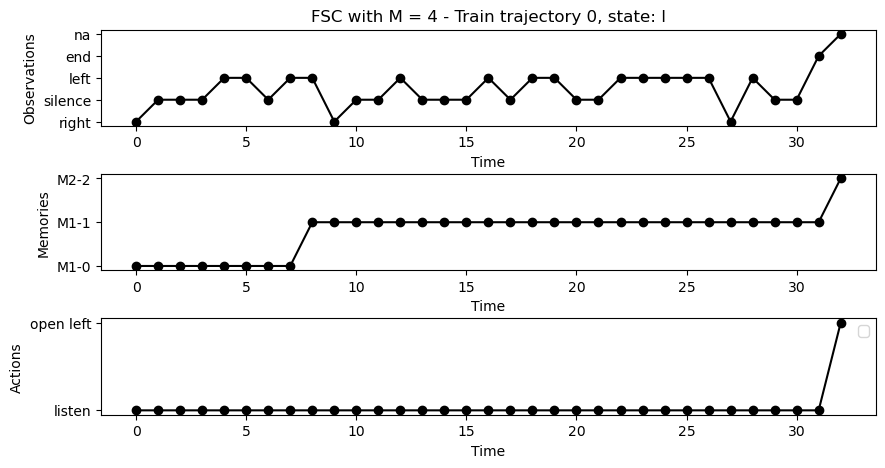

In [31]:
trj = generated_trajectories_train[idx_trj_tr][idx_trj_tr_rep]
fig, ax = FSC_M4.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M4.M) + ' - Train trajectory ' + str(idx_trj_tr) + ", state: " + states_data_train[idx_trj_tr])
ax[2].legend(handlelength = 0.5)
plt.show()

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_12841/3999159833.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


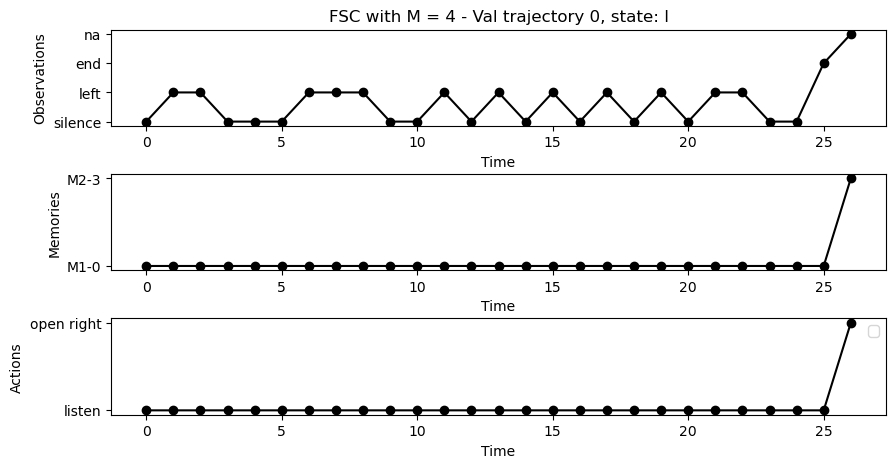

In [32]:
trj = generated_trajectories_val[idx_trj_val][idx_trj_val_rep]
fig, ax = FSC_M4.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M4.M) + ' - Val trajectory ' + str(idx_trj_val) + ", state: " + states_data_val[idx_trj_val])
ax[2].legend(handlelength = 0.5)
plt.show()

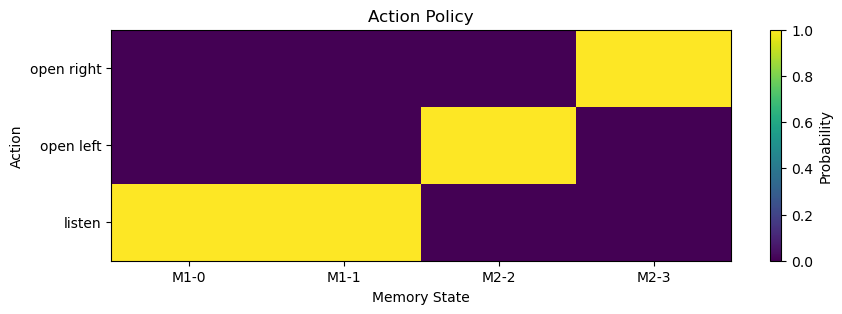

In [33]:
fig, ax = plt.subplots(figsize=(10, 3))
c = ax.pcolormesh(MemSpace_best, ActSpace, FSC_M4.get_action_policy().T)
ax.set_xlabel('Memory State')
ax.set_ylabel('Action')
ax.set_title('Action Policy')
fig.colorbar(c, ax=ax, label='Probability', orientation='vertical')
plt.show()

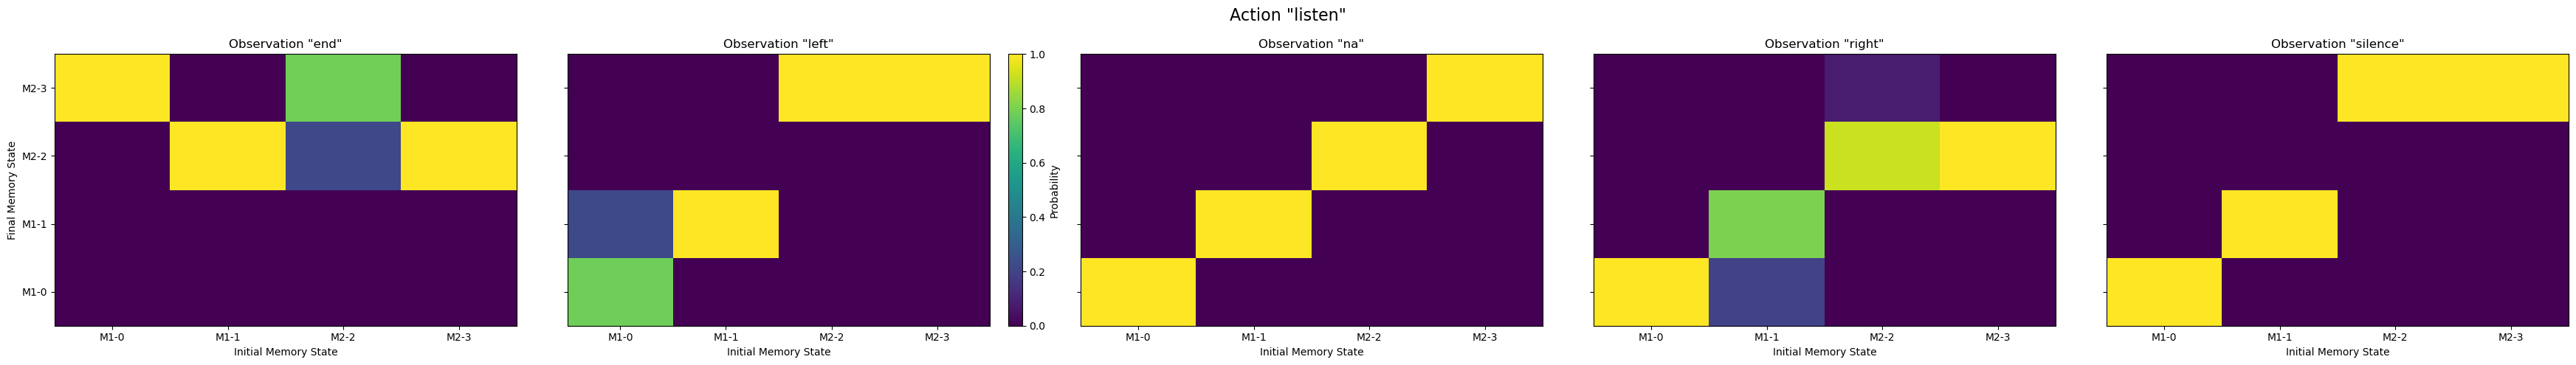

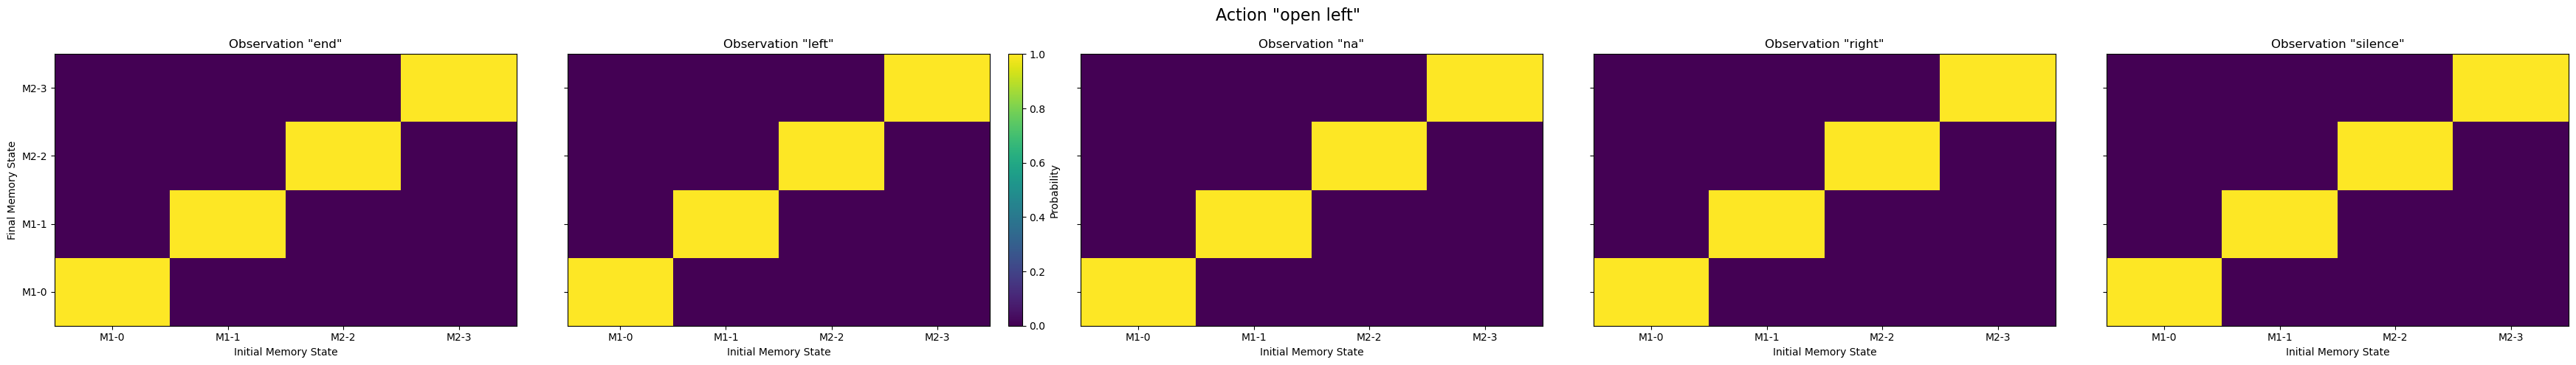

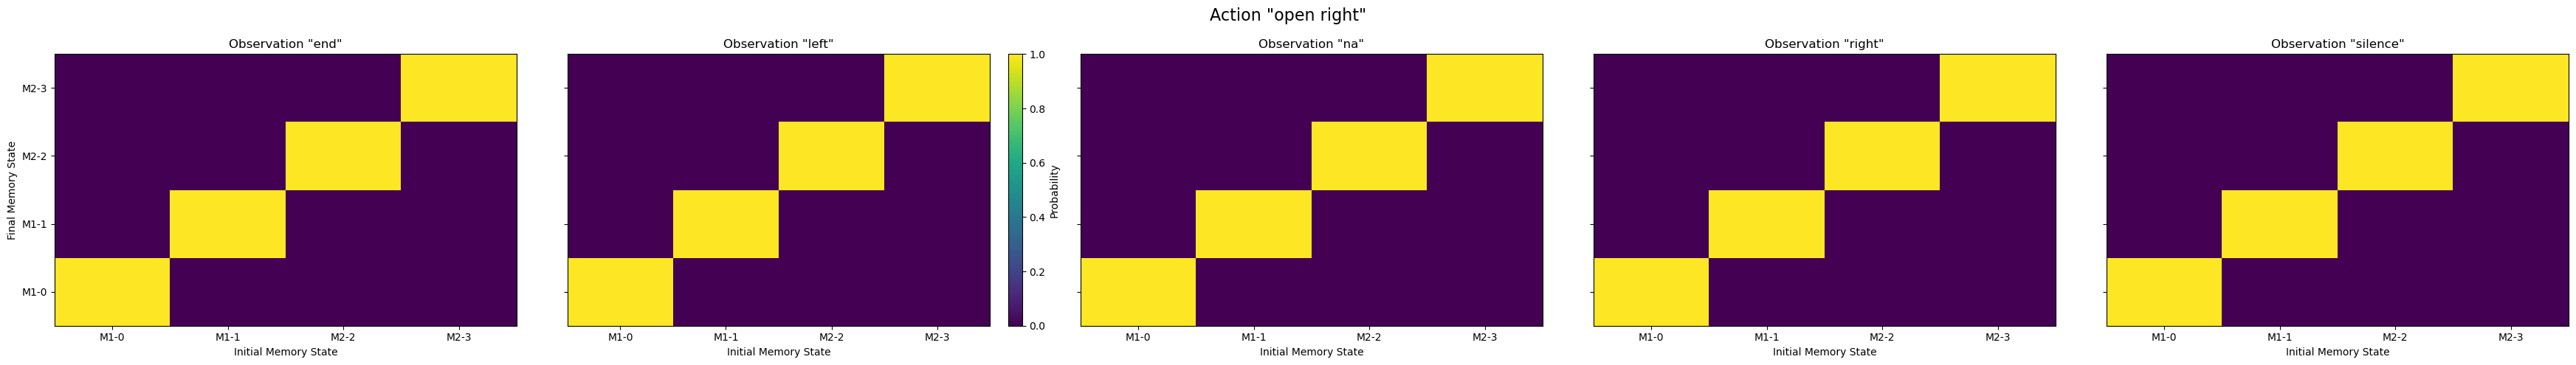

In [34]:
for idx_act in range(len(ActSpace)):
    fig, axs = plt.subplots(1, len(ObsSpace), figsize=(35, 5), sharey=True)
    for idx_obs in range(len(ObsSpace)):
        c = axs[idx_obs].pcolormesh(
            MemSpace_best,
            MemSpace_best,
            FSC_M4.get_memory_transitions()[idx_obs][idx_act].T
        )
        axs[idx_obs].set_xlabel('Initial Memory State')
        axs[idx_obs].set_title(f'Observation "{ObsSpace[idx_obs]}"')
        fig.suptitle(f'Action "{ActSpace[idx_act]}"', fontsize=16)
        if idx_obs == 0:
            axs[idx_obs].set_ylabel('Final Memory State')
        if idx_obs == 1:
            fig.colorbar(c, ax=axs[idx_obs], label='Probability', orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

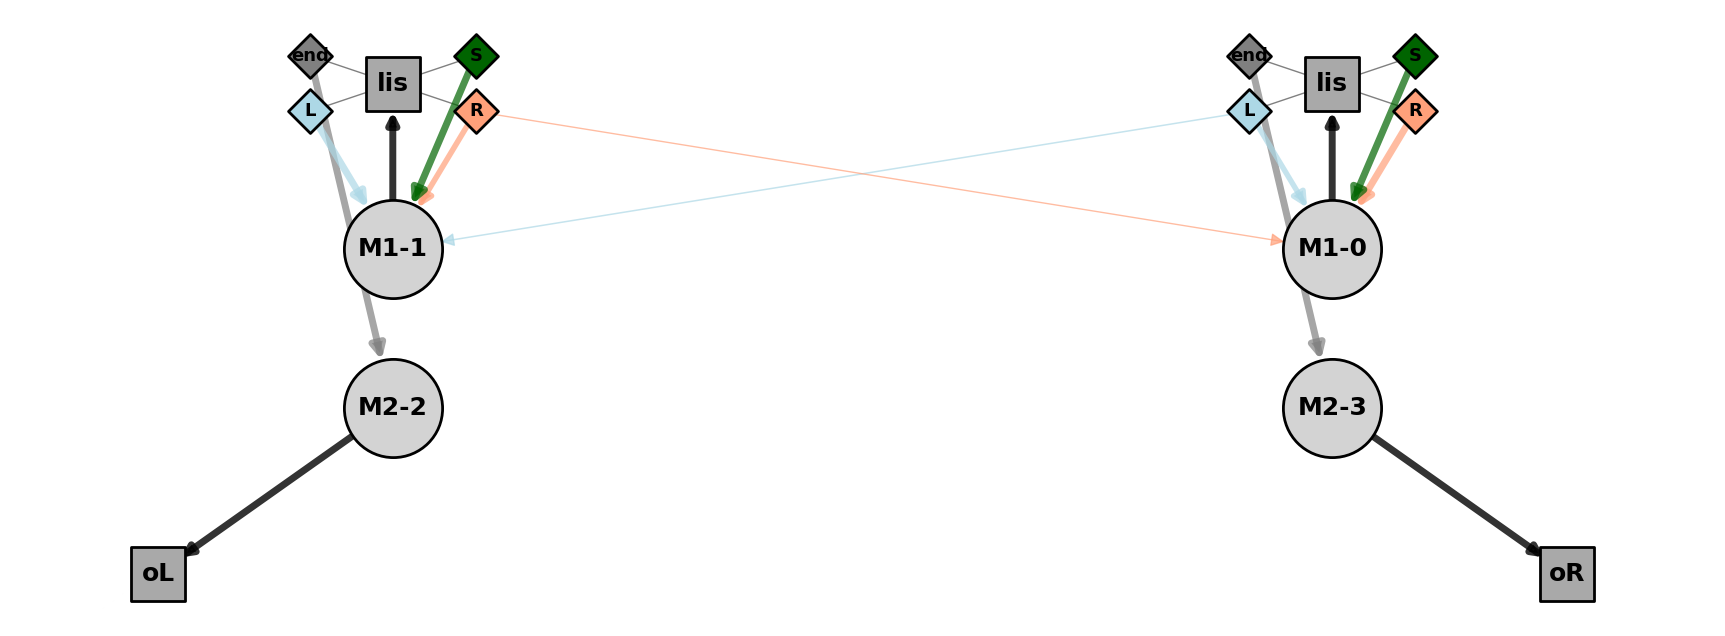

In [35]:
chain_ordering = [1, 0, 2, 3]

fig, ax = plt.subplots(figsize=(22, 8))
FSC_M4.plot_twolayers_FSC(observation_node_colors=["gray", 'lightblue', "k", 'lightsalmon', "darkgreen"],
                               memory_ordering = chain_ordering,
                               memory_names=MemSpace_best[chain_ordering],
                               action_names=['lis', 'oL', 'oR'], observation_names=["end", 'L', "", 'R', "S"],
                               AllowedObsFromAct = AllowedObsFromAct, obs_rotation=np.pi/4 * 3,
                               ax = ax)
plt.show()

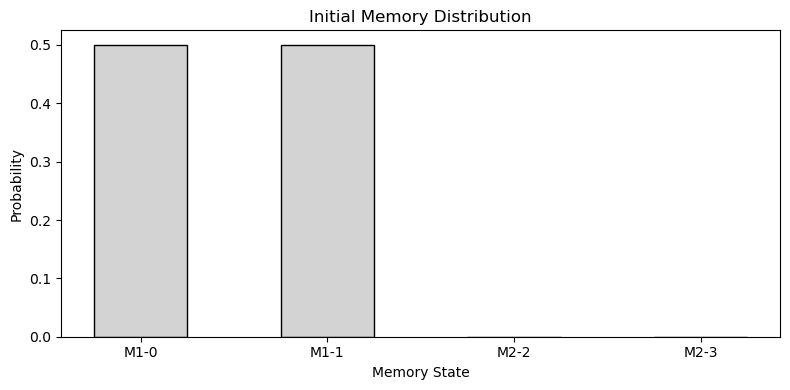

In [37]:
rho = FSC_M4.rho

# rho is the initial distribution of memory states, make an histogram of it
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(rho)), rho, color='lightgray', edgecolor='k', width=0.5)
ax.set_xlabel('Memory State')
ax.set_ylabel('Probability')
ax.set_title('Initial Memory Distribution')
ax.set_xticks(np.arange(len(MemSpace_best)), MemSpace_best)
plt.tight_layout()
plt.show()

In [38]:
generated_observations_train = []
generated_actions_train = []
generated_memories_train = []
for trjseq in generated_trajectories_train:
    for trj in trjseq:
        generated_observations_train.append(trj["observations"])
        generated_actions_train.append(trj["actions"])
        generated_memories_train.append(trj["memories"])

generated_observations_val = []
generated_actions_val = []
generated_memories_val = []
for trjseq in generated_trajectories_val:
    for trj in trjseq:
        generated_observations_val.append(trj["observations"])
        generated_actions_val.append(trj["actions"])
        generated_memories_val.append(trj["memories"])

In [39]:
num_bins = 20
bins_diff_train_gen, prob_R_train_gen, mem_occ_train_gen = compute_right_vs_obsdiff_wmem(generated_observations_train,
                                                                                         generated_actions_train,
                                                                                         generated_memories_train,
                                                                                         FSC_M4.M,
                                                                                         num_bins)
bins_diff_val_gen, prob_R_val_gen, mem_occ_val_gen = compute_right_vs_obsdiff_wmem(generated_observations_val,
                                                                                   generated_actions_val,
                                                                                   generated_memories_val,
                                                                                   FSC_M4.M,
                                                                                   num_bins)

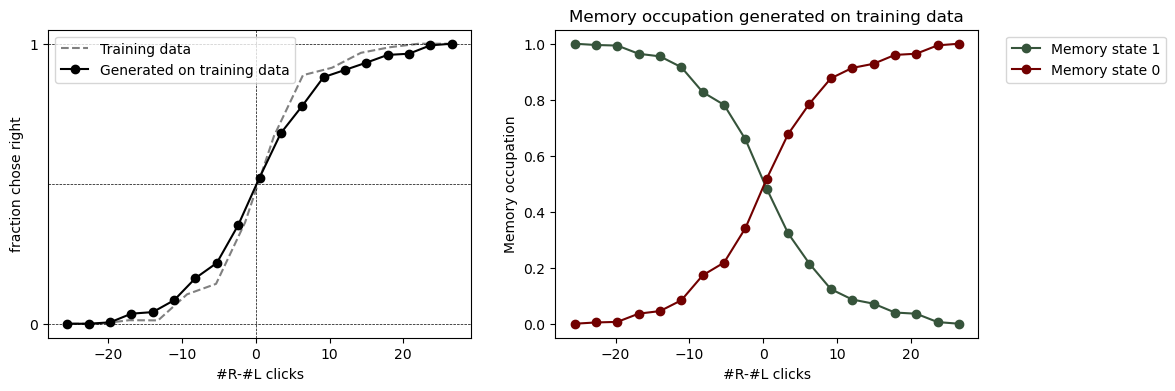

In [40]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_train, prob_R_train, ls = '--', label='Training data', c = "gray")
axs[0].plot(bins_diff_train_gen, prob_R_train_gen, '-o', label='Generated on training data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M4.M - 2]):
    color_mem = memories_cmap(idx_seq / (FSC_M4.M - 3))
    axs[1].plot(bins_diff_train_gen, mem_occ_train_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)
    
axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on training data')
plt.show()

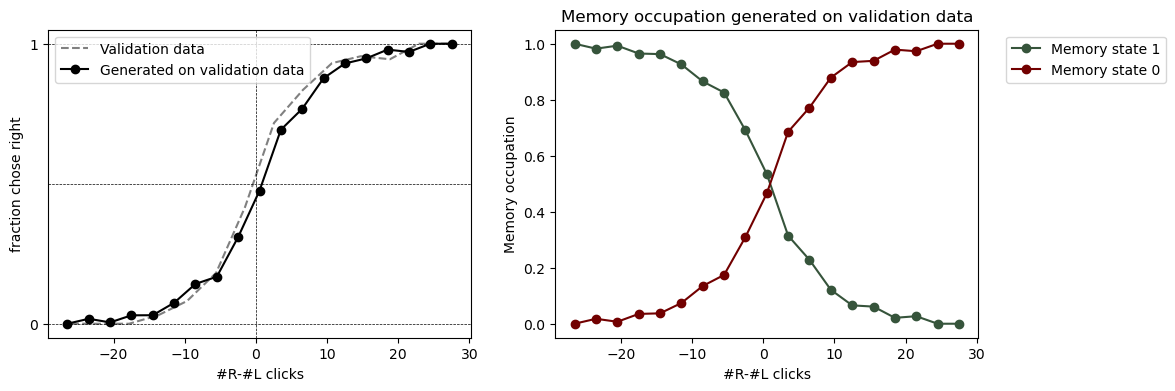

In [41]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_val, prob_R_val, ls = '--', label='Validation data', c = "gray")
axs[0].plot(bins_diff_val_gen, prob_R_val_gen, '-o', label='Generated on validation data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M4.M - 2]):
    color_mem = memories_cmap(idx_seq / (FSC_M4.M - 3))
    axs[1].plot(bins_diff_val_gen, mem_occ_val_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)

axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on validation data')
plt.show()

# Analysis for the best FSC with M = 5

In [42]:
idx_best_M5 = 3
FSC_M5 = best_FSC_M_list[idx_best_M5]
MemSpace_best = MemSpaces_list[idx_best_M5]

print("Best loss for M =", FSC_M5.M, "is", FSC_M5.best_loss)

FSC_M5.set_mode("generation")

generated_trajectories_train = []
for obs_seq in observations_data_train:
    trj = FSC_M5.generate_trajectories(obs_from_act = True,
                                   NTraj = 100,
                                   observations = obs_seq)
    generated_trajectories_train.append(trj)

generated_trajectories_val = []
for obs_seq in observations_data_val:
    trj = FSC_M5.generate_trajectories(obs_from_act = True,
                                   NTraj = 100,
                                   observations = obs_seq)
    generated_trajectories_val.append(trj)

generated_trajectories_all = generated_trajectories_train + generated_trajectories_val

Best loss for M = 5 is 0.3508233751497553


In [44]:
idx_trj_tr = 0
idx_trj_tr_rep = 0
idx_trj_val = 0
idx_trj_val_rep = 0

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_12841/4005720452.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


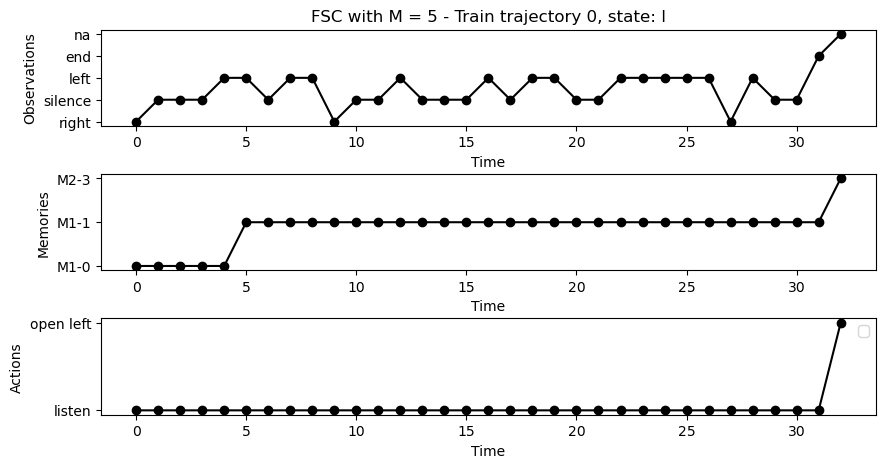

In [45]:
trj = generated_trajectories_train[idx_trj_tr][idx_trj_tr_rep]
fig, ax = FSC_M5.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M5.M) + ' - Train trajectory ' + str(idx_trj_tr) + ", state: " + states_data_train[idx_trj_tr])
ax[2].legend(handlelength = 0.5)
plt.show()

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_12841/3619156561.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


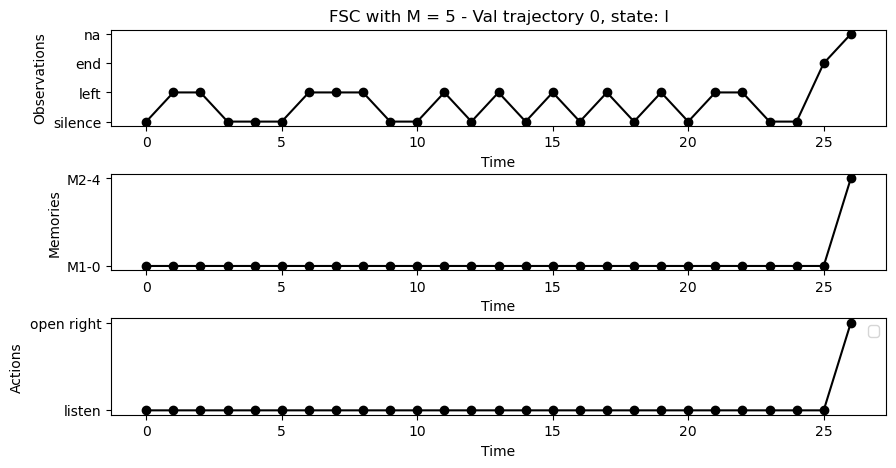

In [46]:
trj = generated_trajectories_val[idx_trj_val][idx_trj_val_rep]
fig, ax = FSC_M5.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M5.M) + ' - Val trajectory ' + str(idx_trj_val) + ", state: " + states_data_val[idx_trj_val])
ax[2].legend(handlelength = 0.5)
plt.show()

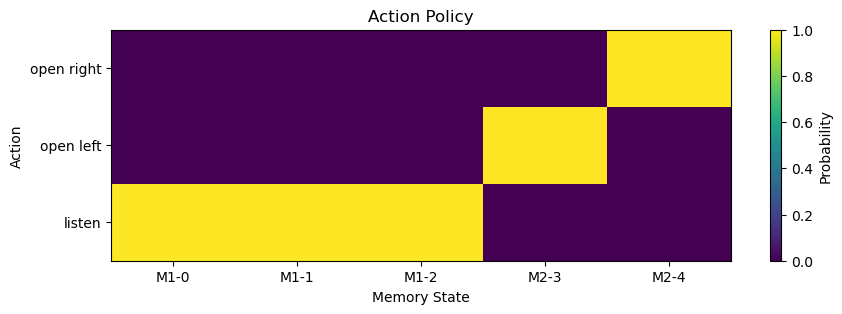

In [47]:
fig, ax = plt.subplots(figsize=(10, 3))
c = ax.pcolormesh(MemSpace_best, ActSpace, FSC_M5.get_action_policy().T)
ax.set_xlabel('Memory State')
ax.set_ylabel('Action')
ax.set_title('Action Policy')
fig.colorbar(c, ax=ax, label='Probability', orientation='vertical')
plt.show()

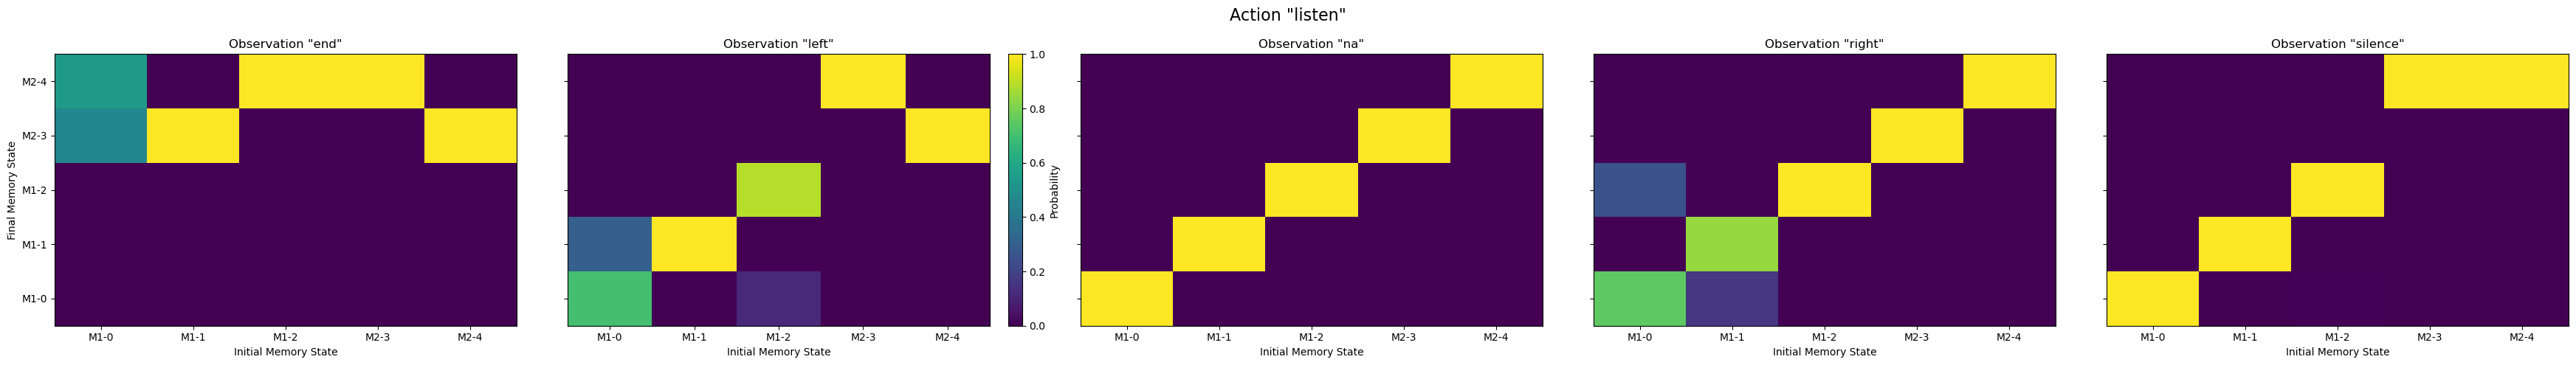

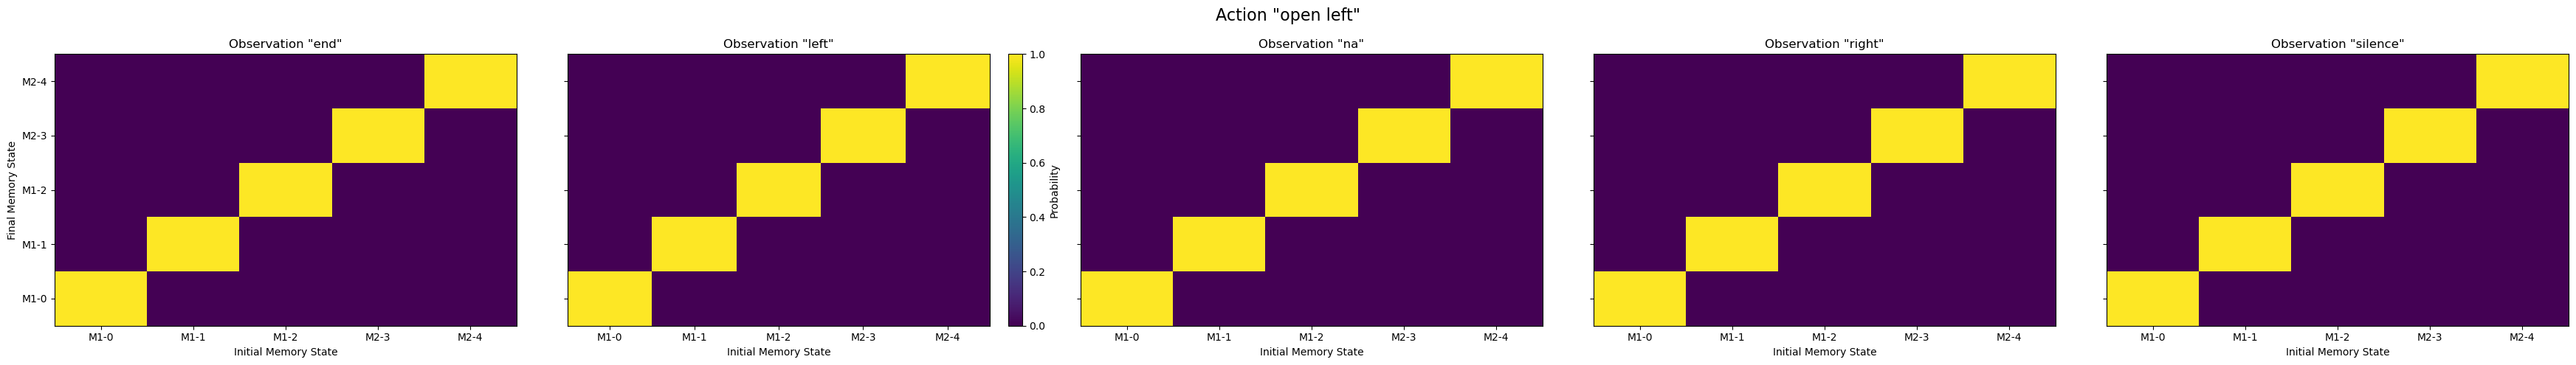

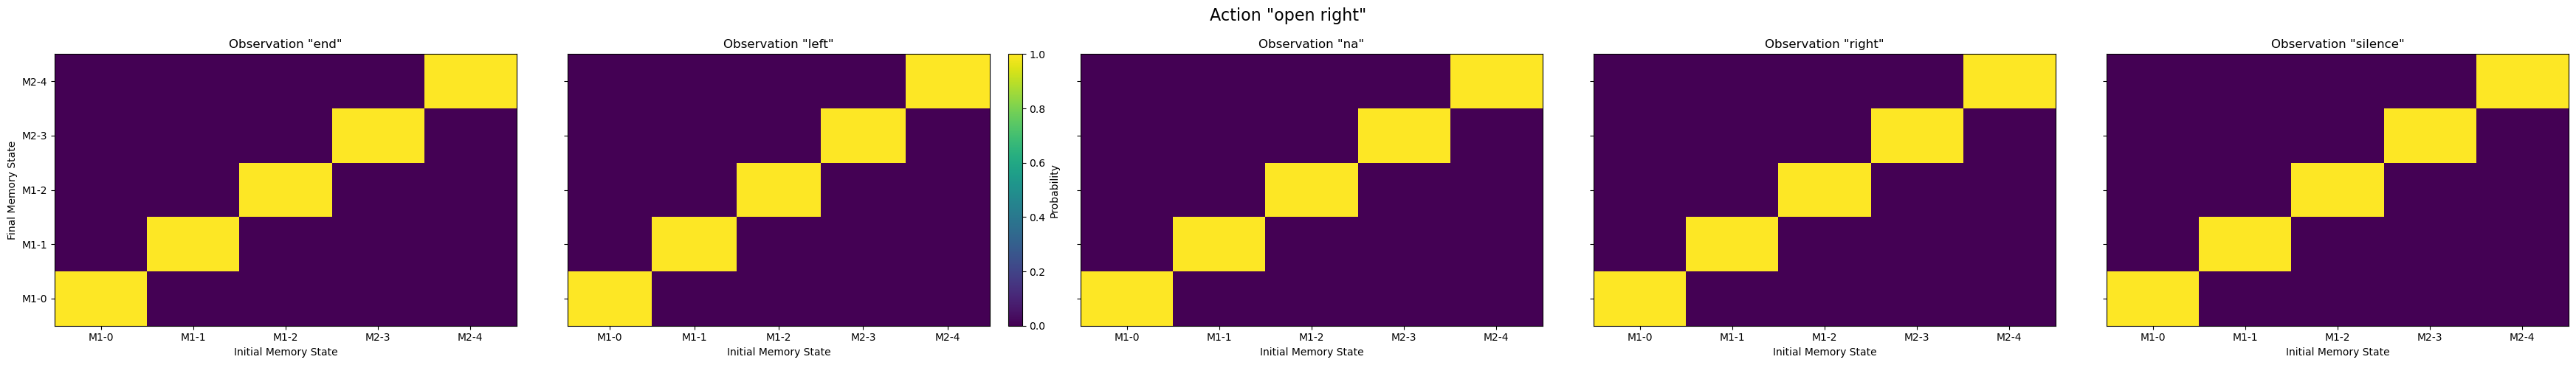

In [48]:
for idx_act in range(len(ActSpace)):
    fig, axs = plt.subplots(1, len(ObsSpace), figsize=(35, 5), sharey=True)
    for idx_obs in range(len(ObsSpace)):
        c = axs[idx_obs].pcolormesh(
            MemSpace_best,
            MemSpace_best,
            FSC_M5.get_memory_transitions()[idx_obs][idx_act].T
        )
        axs[idx_obs].set_xlabel('Initial Memory State')
        axs[idx_obs].set_title(f'Observation "{ObsSpace[idx_obs]}"')
        fig.suptitle(f'Action "{ActSpace[idx_act]}"', fontsize=16)
        if idx_obs == 0:
            axs[idx_obs].set_ylabel('Final Memory State')
        if idx_obs == 1:
            fig.colorbar(c, ax=axs[idx_obs], label='Probability', orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

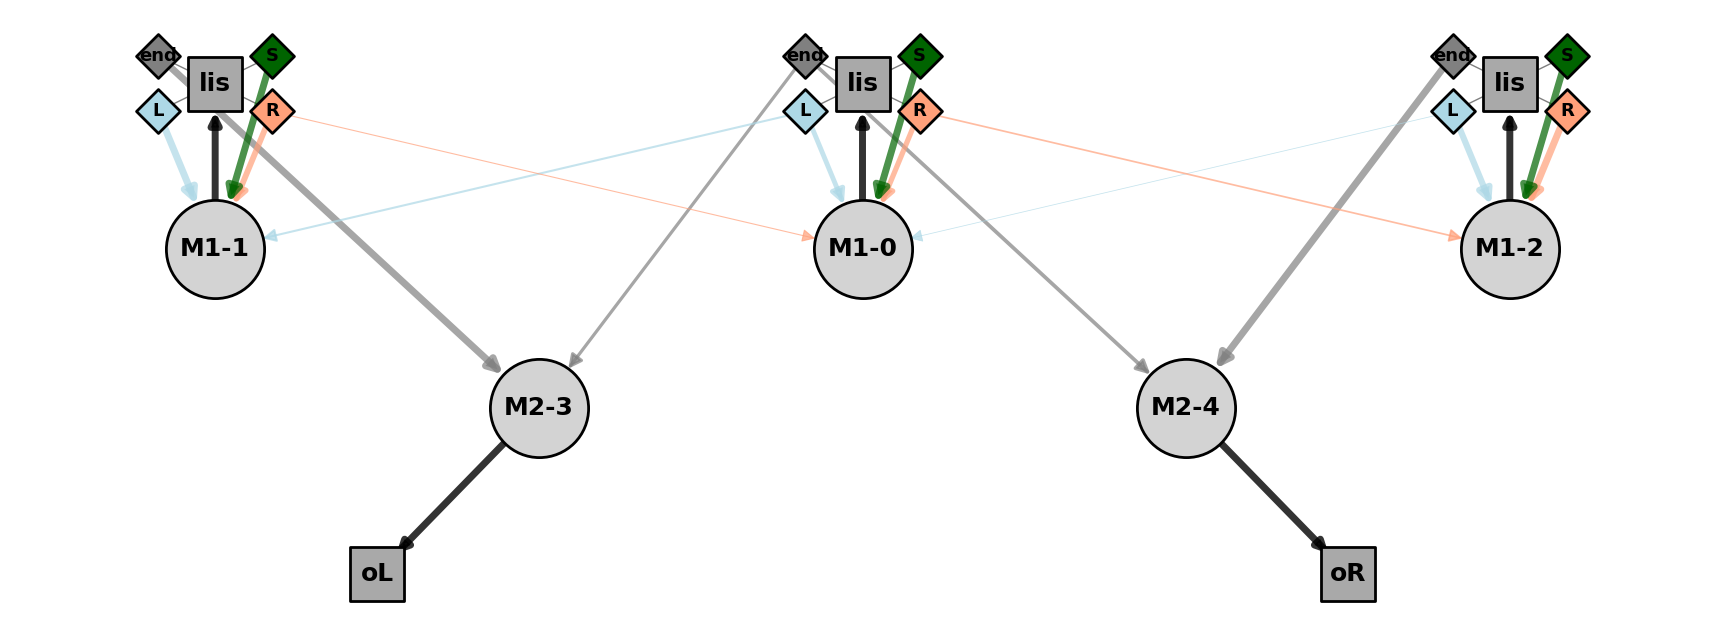

In [49]:
chain_ordering = [1, 0, 2, 3, 4]

fig, ax = plt.subplots(figsize=(22, 8))
FSC_M5.plot_twolayers_FSC(observation_node_colors=["gray", 'lightblue', "k", 'lightsalmon', "darkgreen"],
                               memory_ordering = chain_ordering,
                               memory_names=MemSpace_best[chain_ordering],
                               action_names=['lis', 'oL', 'oR'], observation_names=["end", 'L', "", 'R', "S"],
                               AllowedObsFromAct = AllowedObsFromAct, obs_rotation=np.pi/4 * 3,
                               ax = ax)
plt.show()

In [50]:
FSC_M5.get_memory_transitions()[idx_obs_right, idx_listen, 1], FSC_M5.get_memory_transitions()[idx_obs_left, idx_listen, 0]

(array([1.58549197e-01, 8.41450803e-01, 2.34974429e-12, 0.00000000e+00,
        0.00000000e+00]),
 array([7.00999163e-01, 2.99000837e-01, 4.93148756e-25, 0.00000000e+00,
        0.00000000e+00]))

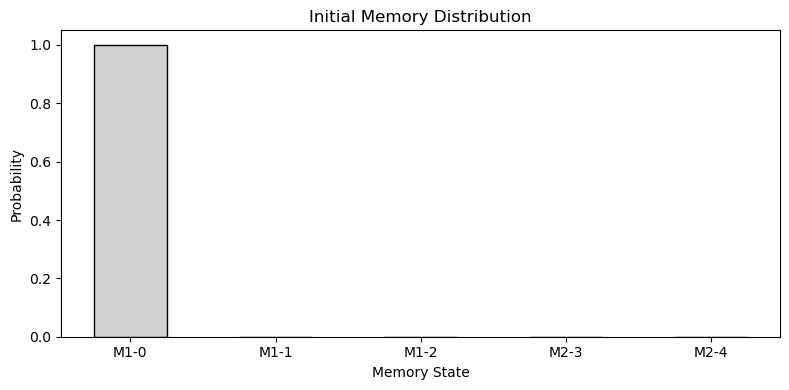

In [51]:
rho = FSC_M5.rho

# rho is the initial distribution of memory states, make an histogram of it
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(rho)), rho, color='lightgray', edgecolor='k', width=0.5)
ax.set_xlabel('Memory State')
ax.set_ylabel('Probability')
ax.set_title('Initial Memory Distribution')
ax.set_xticks(np.arange(len(MemSpace_best)), MemSpace_best)
plt.tight_layout()
plt.show()

In [52]:
generated_observations_train = []
generated_actions_train = []
generated_memories_train = []
for trjseq in generated_trajectories_train:
    for trj in trjseq:
        generated_observations_train.append(trj["observations"])
        generated_actions_train.append(trj["actions"])
        generated_memories_train.append(trj["memories"])

generated_observations_val = []
generated_actions_val = []
generated_memories_val = []
for trjseq in generated_trajectories_val:
    for trj in trjseq:
        generated_observations_val.append(trj["observations"])
        generated_actions_val.append(trj["actions"])
        generated_memories_val.append(trj["memories"])

In [53]:
num_bins = 20
bins_diff_train_gen, prob_R_train_gen, mem_occ_train_gen = compute_right_vs_obsdiff_wmem(generated_observations_train,
                                                                                         generated_actions_train,
                                                                                         generated_memories_train,
                                                                                         FSC_M5.M,
                                                                                         num_bins)
bins_diff_val_gen, prob_R_val_gen, mem_occ_val_gen = compute_right_vs_obsdiff_wmem(generated_observations_val,
                                                                                   generated_actions_val,
                                                                                   generated_memories_val,
                                                                                   FSC_M5.M,
                                                                                   num_bins)

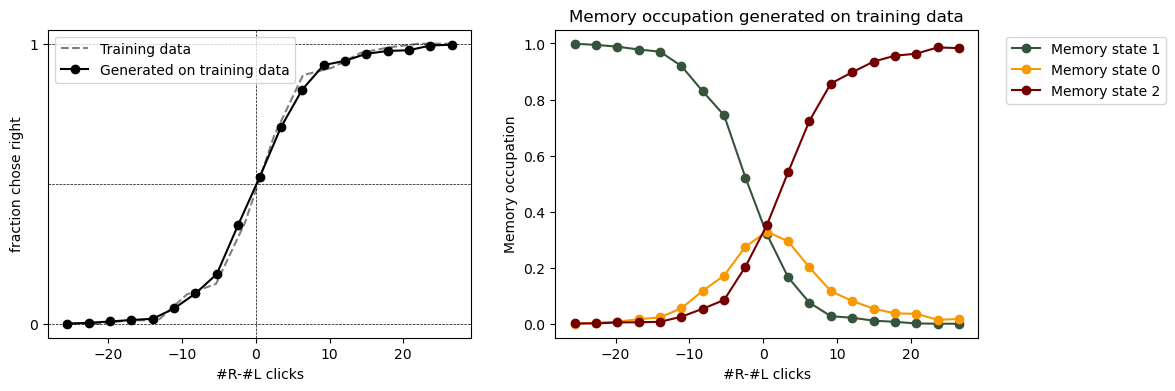

In [54]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_train, prob_R_train, ls = '--', label='Training data', c = "gray")
axs[0].plot(bins_diff_train_gen, prob_R_train_gen, '-o', label='Generated on training data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M5.M - 2]):
    color_mem = memories_cmap(idx_seq / (FSC_M5.M - 3))
    axs[1].plot(bins_diff_train_gen, mem_occ_train_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)
    
axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on training data')
plt.show()

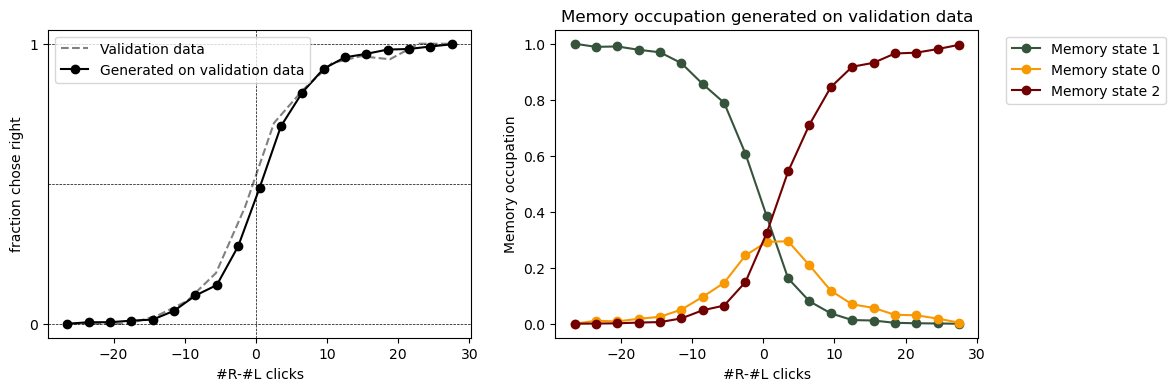

In [55]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_val, prob_R_val, ls = '--', label='Validation data', c = "gray")
axs[0].plot(bins_diff_val_gen, prob_R_val_gen, '-o', label='Generated on validation data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M5.M - 2]):
    color_mem = memories_cmap(idx_seq / (FSC_M5.M - 3))
    axs[1].plot(bins_diff_val_gen, mem_occ_val_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)

axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on validation data')
plt.show()

# Analysis for the best FSC with M = 6

In [611]:
idx_best_M6 = 4
FSC_M6 = best_FSC_M_list[idx_best_M6]
MemSpace_best = MemSpaces_list[idx_best_M6]

print("Best loss for M =", FSC_M6.M, "is", FSC_M6.best_loss)

FSC_M6.set_mode("generation")

generated_trajectories_train = []
for obs_seq in observations_data_train:
    trj = FSC_M6.generate_trajectories(obs_from_act = True,
                                   NTraj = 100,
                                   observations = obs_seq)
    generated_trajectories_train.append(trj)

generated_trajectories_val = []
for obs_seq in observations_data_val:
    trj = FSC_M6.generate_trajectories(obs_from_act = True,
                                   NTraj = 100,
                                   observations = obs_seq)
    generated_trajectories_val.append(trj)

generated_trajectories_all = generated_trajectories_train + generated_trajectories_val

Best loss for M = 6 is 0.34963869050952506


In [613]:
idx_trj_tr = 0
idx_trj_tr_rep = 0
idx_trj_val = 0
idx_trj_val_rep = 0

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_3604/2380237517.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


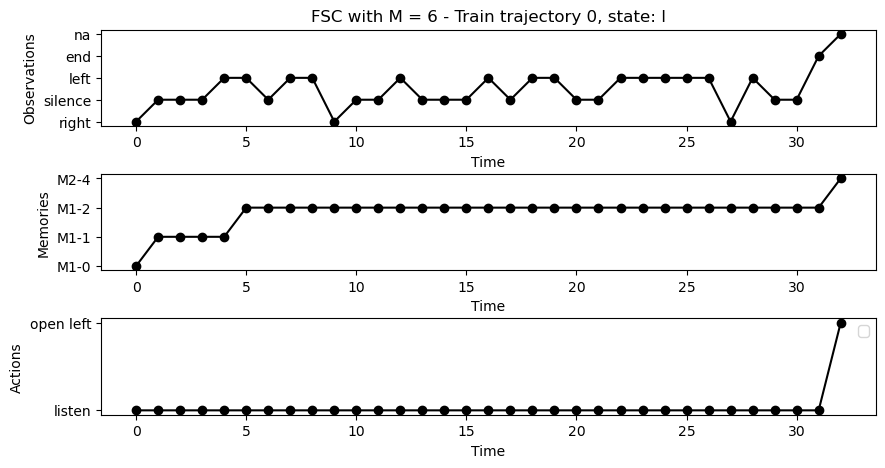

In [614]:
trj = generated_trajectories_train[idx_trj_tr][idx_trj_tr_rep]
fig, ax = FSC_M6.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M6.M) + ' - Train trajectory ' + str(idx_trj_tr) + ", state: " + states_data_train[idx_trj_tr])
ax[2].legend(handlelength = 0.5)
plt.show()

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_3604/608930668.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


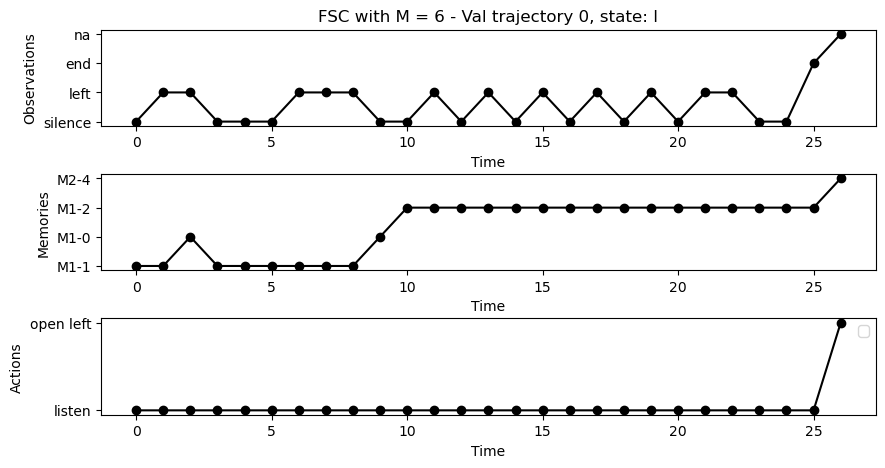

In [615]:
trj = generated_trajectories_val[idx_trj_val][idx_trj_val_rep]
fig, ax = FSC_M6.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M6.M) + ' - Val trajectory ' + str(idx_trj_val) + ", state: " + states_data_val[idx_trj_val])
ax[2].legend(handlelength = 0.5)
plt.show()

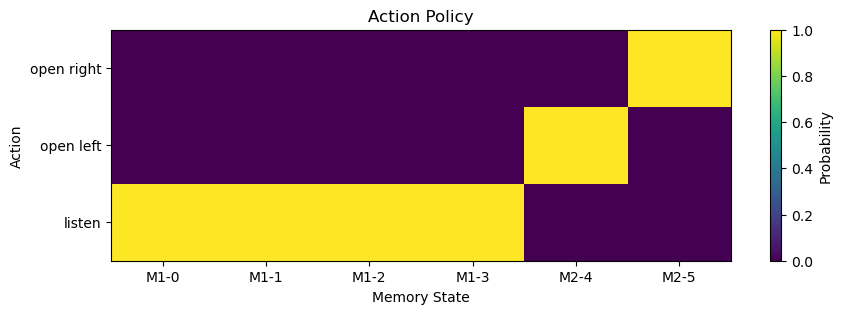

In [616]:
fig, ax = plt.subplots(figsize=(10, 3))
c = ax.pcolormesh(MemSpace_best, ActSpace, FSC_M6.get_action_policy().T)
ax.set_xlabel('Memory State')
ax.set_ylabel('Action')
ax.set_title('Action Policy')
fig.colorbar(c, ax=ax, label='Probability', orientation='vertical')
plt.show()

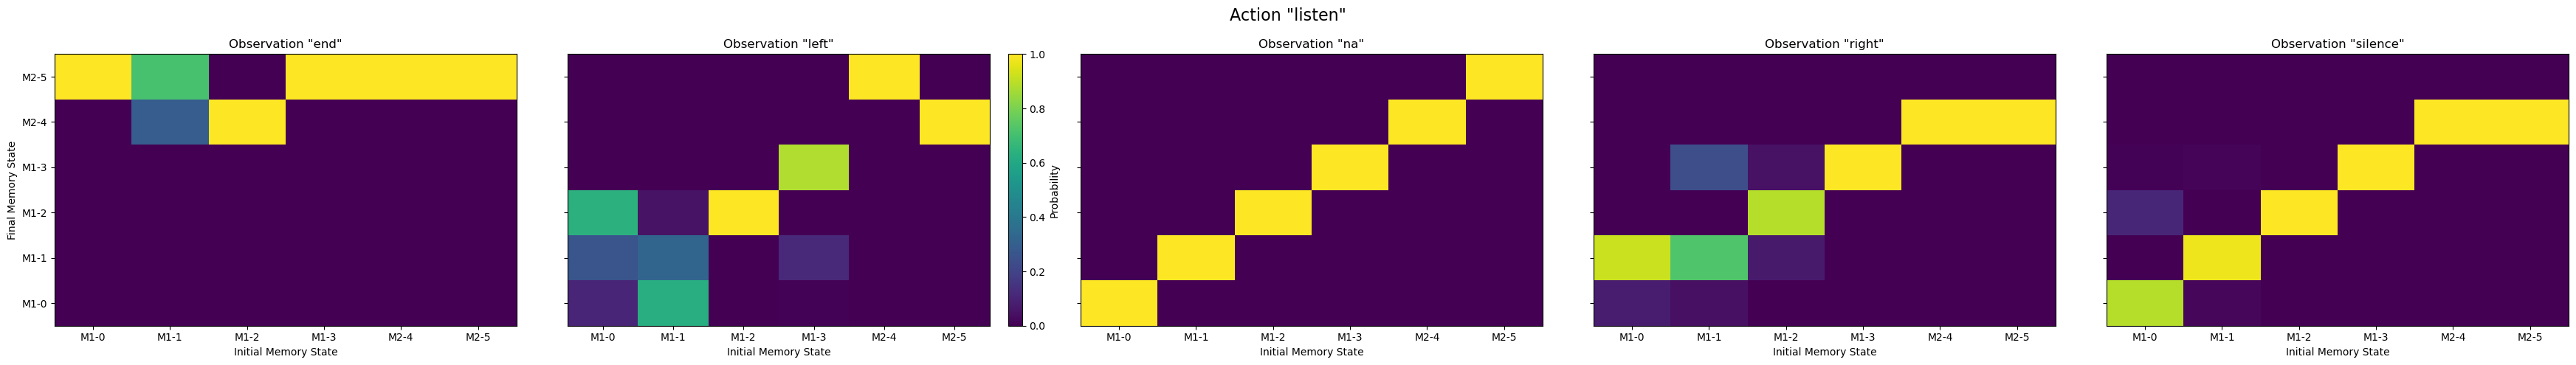

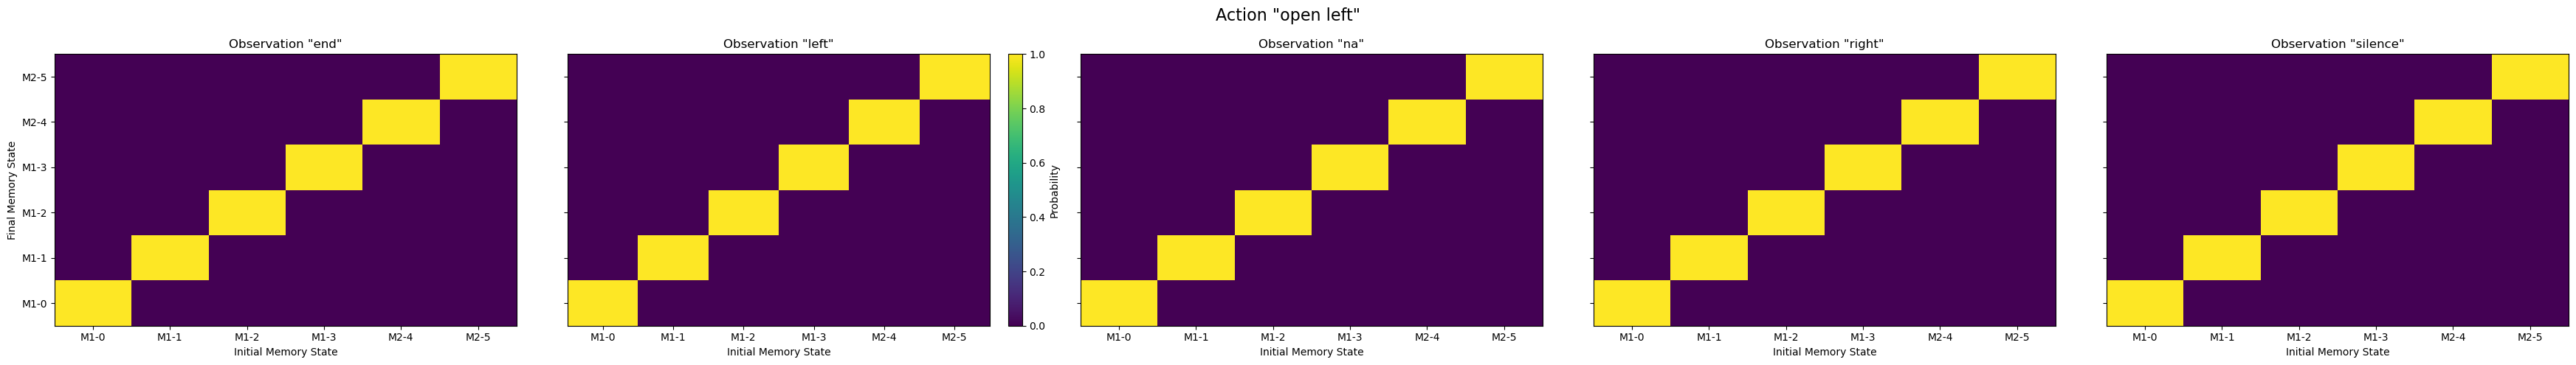

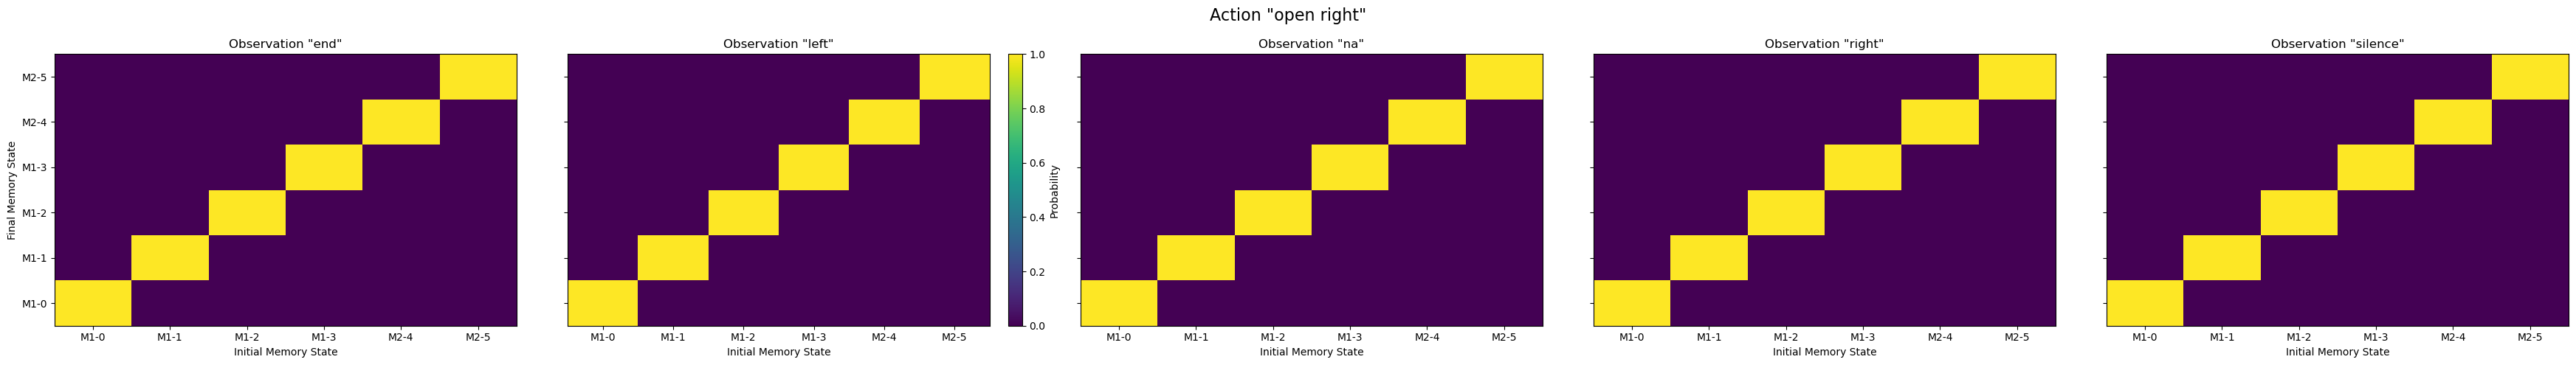

In [617]:
for idx_act in range(len(ActSpace)):
    fig, axs = plt.subplots(1, len(ObsSpace), figsize=(35, 5), sharey=True)
    for idx_obs in range(len(ObsSpace)):
        c = axs[idx_obs].pcolormesh(
            MemSpace_best,
            MemSpace_best,
            FSC_M6.get_memory_transitions()[idx_obs][idx_act].T
        )
        axs[idx_obs].set_xlabel('Initial Memory State')
        axs[idx_obs].set_title(f'Observation "{ObsSpace[idx_obs]}"')
        fig.suptitle(f'Action "{ActSpace[idx_act]}"', fontsize=16)
        if idx_obs == 0:
            axs[idx_obs].set_ylabel('Final Memory State')
        if idx_obs == 1:
            fig.colorbar(c, ax=axs[idx_obs], label='Probability', orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

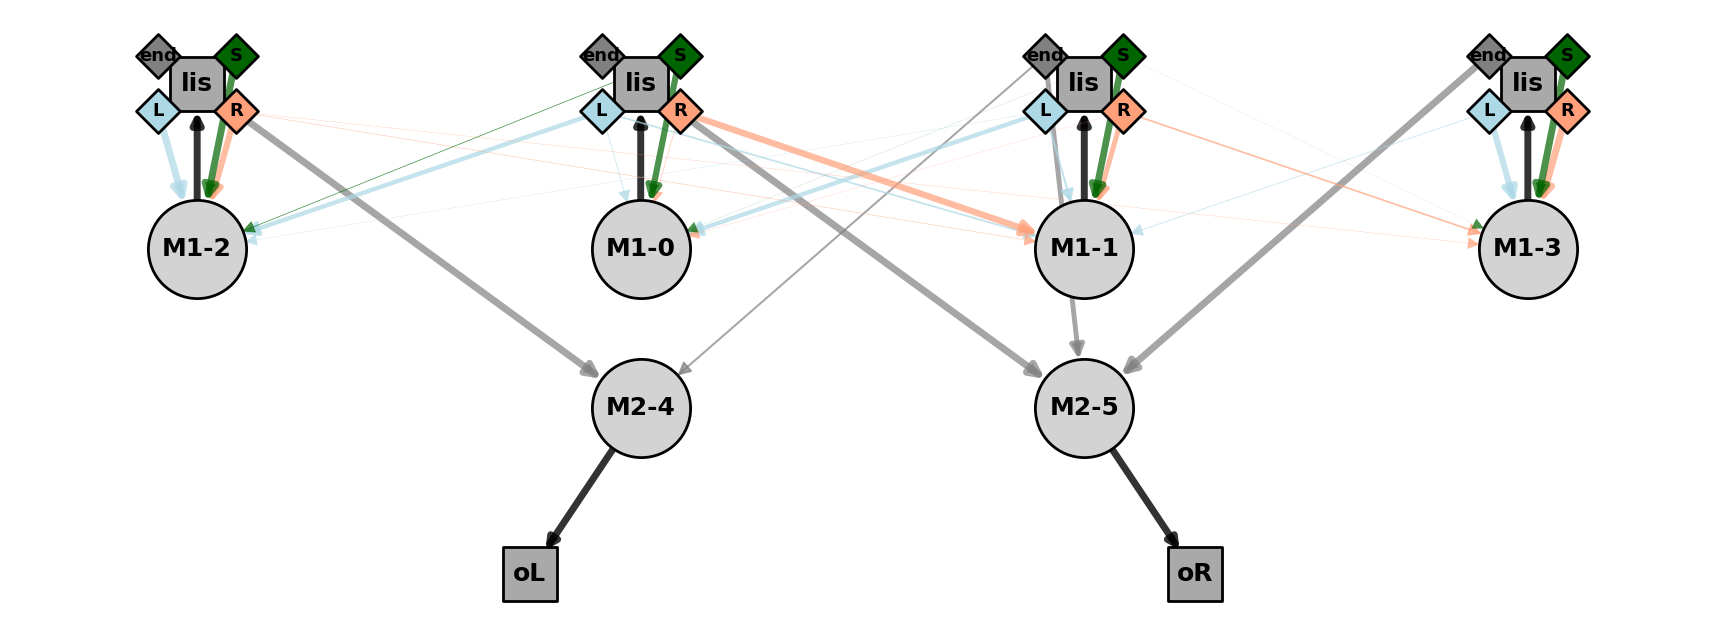

In [624]:
chain_ordering = [2, 0, 1, 3, 4, 5]

fig, ax = plt.subplots(figsize=(22, 8))
FSC_M6.plot_twolayers_FSC(observation_node_colors=["gray", 'lightblue', "k", 'lightsalmon', "darkgreen"],
                               memory_ordering = chain_ordering,
                               memory_names=MemSpace_best[chain_ordering],
                               action_names=['lis', 'oL', 'oR'], observation_names=["end", 'L', "", 'R', "S"],
                               AllowedObsFromAct = AllowedObsFromAct, obs_rotation=np.pi/4 * 3,
                               ax = ax)
plt.show()

In [625]:
FSC_M6.get_memory_transitions()[idx_obs_right, idx_listen, 1], FSC_M6.get_memory_transitions()[idx_obs_left, idx_listen, 0]

(array([3.98431853e-02, 7.22936341e-01, 2.84025217e-06, 2.37217633e-01,
        0.00000000e+00, 0.00000000e+00]),
 array([1.04393853e-01, 2.58178969e-01, 6.37427178e-01, 1.01557321e-27,
        0.00000000e+00, 0.00000000e+00]))

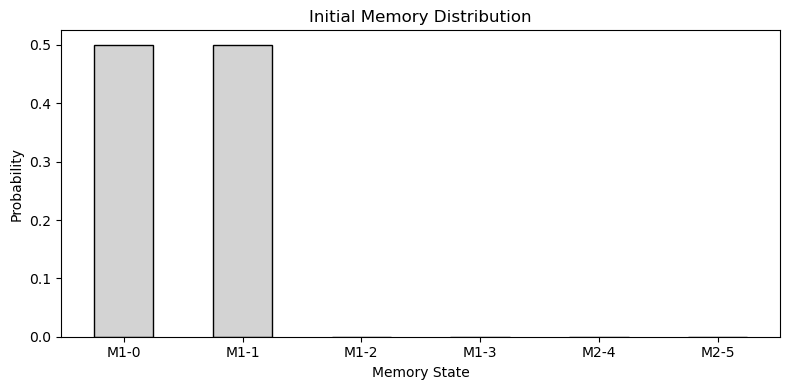

In [626]:
rho = FSC_M6.rho

# rho is the initial distribution of memory states, make an histogram of it
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(rho)), rho, color='lightgray', edgecolor='k', width=0.5)
ax.set_xlabel('Memory State')
ax.set_ylabel('Probability')
ax.set_title('Initial Memory Distribution')
ax.set_xticks(np.arange(len(MemSpace_best)), MemSpace_best)
plt.tight_layout()
plt.show()

In [627]:
generated_observations_train = []
generated_actions_train = []
generated_memories_train = []
for trjseq in generated_trajectories_train:
    for trj in trjseq:
        generated_observations_train.append(trj["observations"])
        generated_actions_train.append(trj["actions"])
        generated_memories_train.append(trj["memories"])

generated_observations_val = []
generated_actions_val = []
generated_memories_val = []
for trjseq in generated_trajectories_val:
    for trj in trjseq:
        generated_observations_val.append(trj["observations"])
        generated_actions_val.append(trj["actions"])
        generated_memories_val.append(trj["memories"])

In [628]:
num_bins = 20
bins_diff_train_gen, prob_R_train_gen, mem_occ_train_gen = compute_right_vs_obsdiff_wmem(generated_observations_train,
                                                                                         generated_actions_train,
                                                                                         generated_memories_train,
                                                                                         FSC_M6.M,
                                                                                         num_bins)
bins_diff_val_gen, prob_R_val_gen, mem_occ_val_gen = compute_right_vs_obsdiff_wmem(generated_observations_val,
                                                                                   generated_actions_val,
                                                                                   generated_memories_val,
                                                                                   FSC_M6.M,
                                                                                   num_bins)

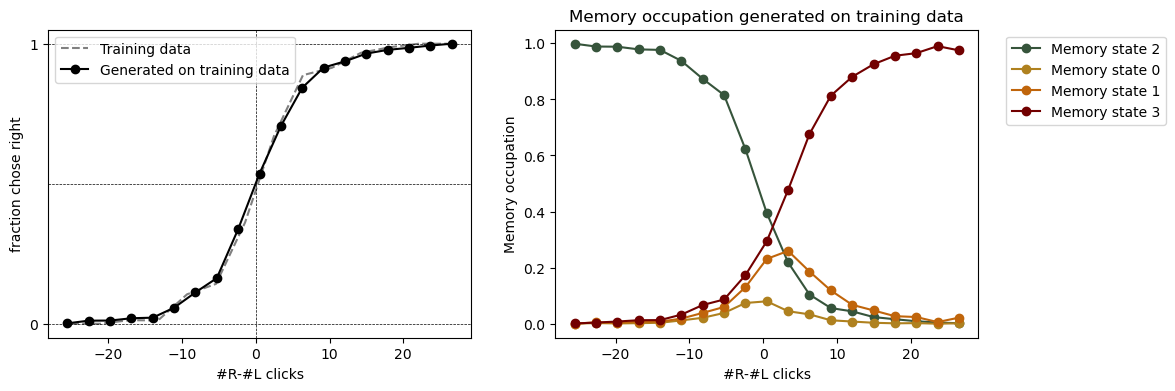

In [629]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_train, prob_R_train, ls = '--', label='Training data', c = "gray")
axs[0].plot(bins_diff_train_gen, prob_R_train_gen, '-o', label='Generated on training data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M6.M - 2]):
    color_mem = memories_cmap(idx_seq / (FSC_M6.M - 3))
    axs[1].plot(bins_diff_train_gen, mem_occ_train_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)
    
axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on training data')
plt.show()

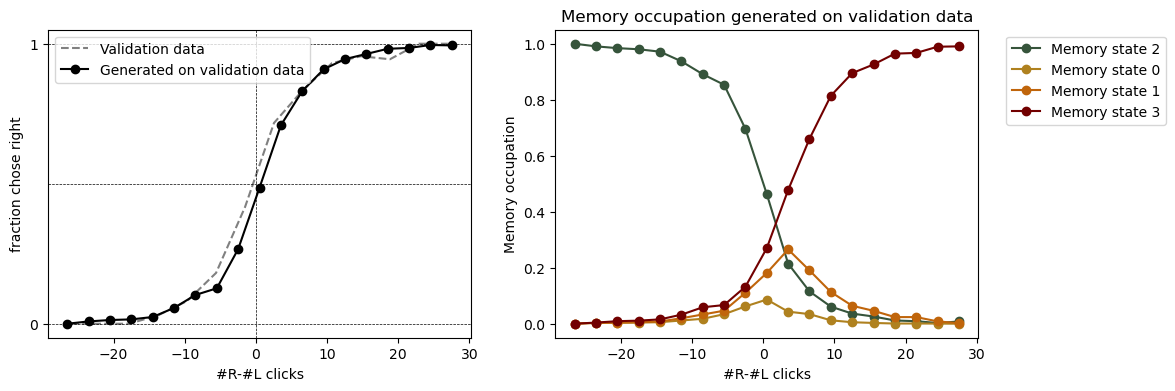

In [630]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_val, prob_R_val, ls = '--', label='Validation data', c = "gray")
axs[0].plot(bins_diff_val_gen, prob_R_val_gen, '-o', label='Generated on validation data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M6.M - 2]):
    color_mem = memories_cmap(idx_seq / (FSC_M6.M - 3))
    axs[1].plot(bins_diff_val_gen, mem_occ_val_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)

axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on validation data')
plt.show()

# Analysis for the best FSC with M = 7

In [633]:
idx_best_M7 = 5
FSC_M7 = best_FSC_M_list[idx_best_M7]
MemSpace_best = MemSpaces_list[idx_best_M7]

print("Best loss for M =", FSC_M7.M, "is", FSC_M7.best_loss)

FSC_M7.set_mode("generation")

generated_trajectories_train = []
for obs_seq in observations_data_train:
    trj = FSC_M7.generate_trajectories(obs_from_act = True,
                                   NTraj = 10,
                                   observations = obs_seq)
    generated_trajectories_train.append(trj)

generated_trajectories_val = []
for obs_seq in observations_data_val:
    trj = FSC_M7.generate_trajectories(obs_from_act = True,
                                   NTraj = 10,
                                   observations = obs_seq)
    generated_trajectories_val.append(trj)

generated_trajectories_all = generated_trajectories_train + generated_trajectories_val

Best loss for M = 7 is 0.349701623127503


In [635]:
idx_trj_tr = 0
idx_trj_tr_rep = 0
idx_trj_val = 0
idx_trj_val_rep = 0

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_3604/4012165527.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


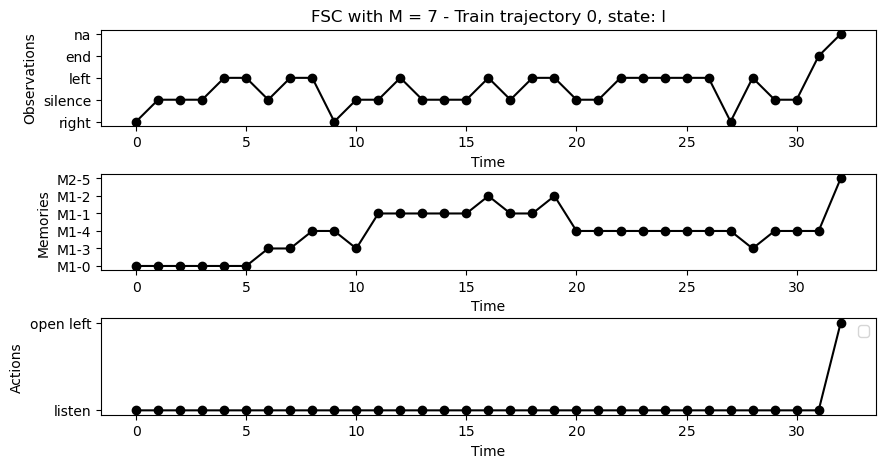

In [636]:
trj = generated_trajectories_train[idx_trj_tr][idx_trj_tr_rep]
fig, ax = FSC_M7.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M7.M) + ' - Train trajectory ' + str(idx_trj_tr) + ", state: " + states_data_train[idx_trj_tr])
ax[2].legend(handlelength = 0.5)
plt.show()

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_3604/3373564327.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(handlelength = 0.5)


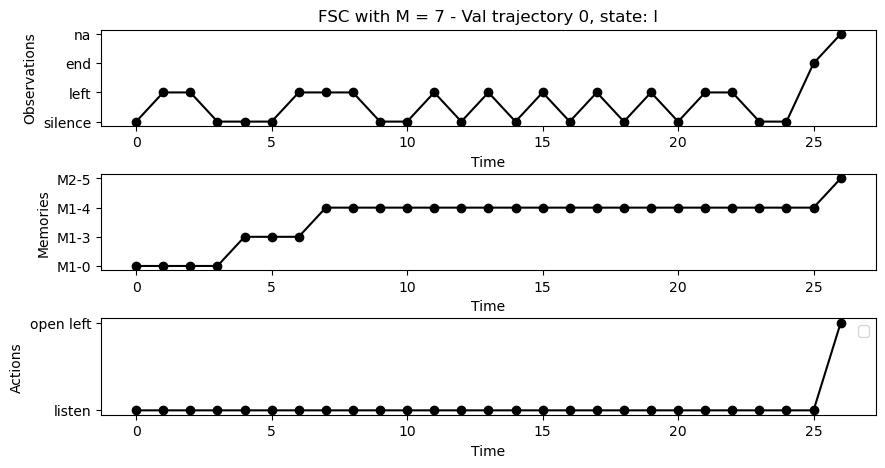

In [637]:
trj = generated_trajectories_val[idx_trj_val][idx_trj_val_rep]
fig, ax = FSC_M7.generator.plot_trajectory(trj)
ax[0].set_title('FSC with M = ' + str(FSC_M7.M) + ' - Val trajectory ' + str(idx_trj_val) + ", state: " + states_data_val[idx_trj_val])
ax[2].legend(handlelength = 0.5)
plt.show()

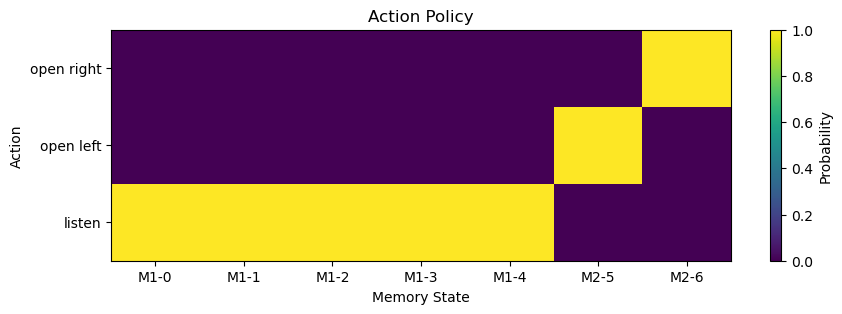

In [638]:
fig, ax = plt.subplots(figsize=(10, 3))
c = ax.pcolormesh(MemSpace_best, ActSpace, FSC_M7.get_action_policy().T)
ax.set_xlabel('Memory State')
ax.set_ylabel('Action')
ax.set_title('Action Policy')
fig.colorbar(c, ax=ax, label='Probability', orientation='vertical')
plt.show()

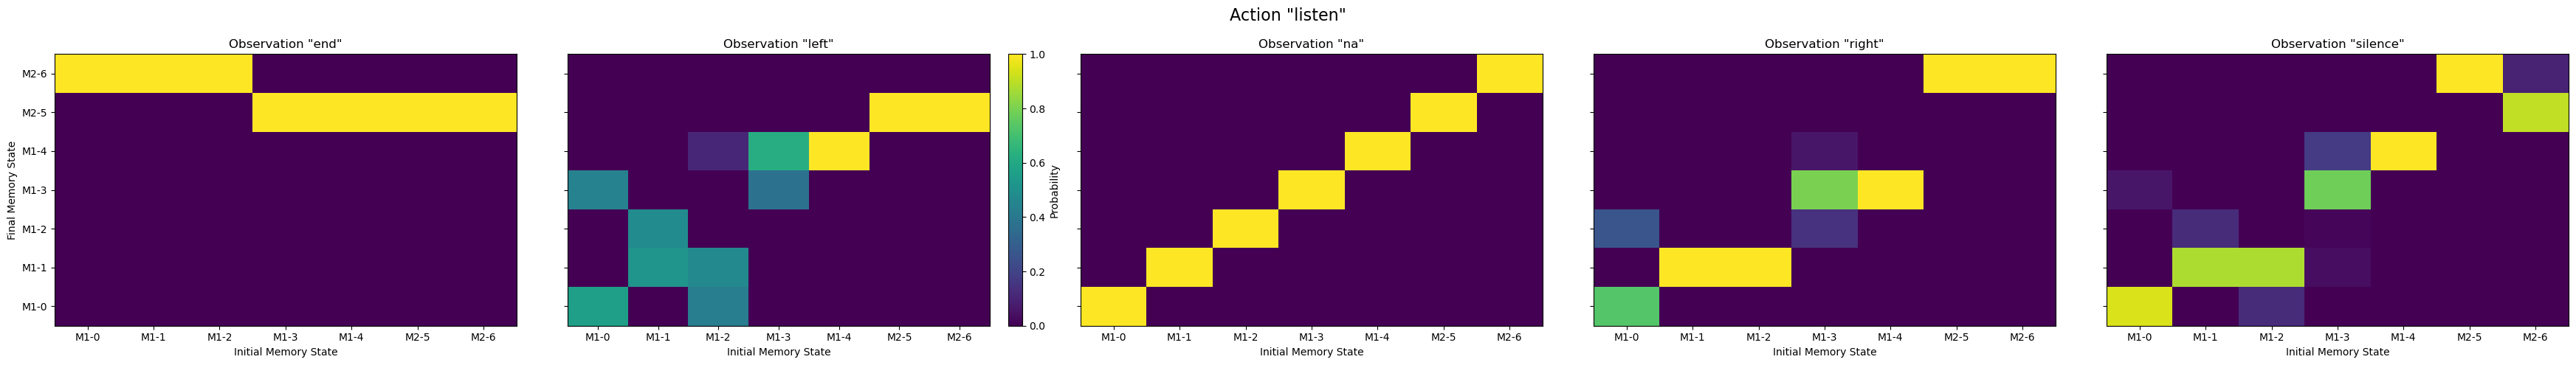

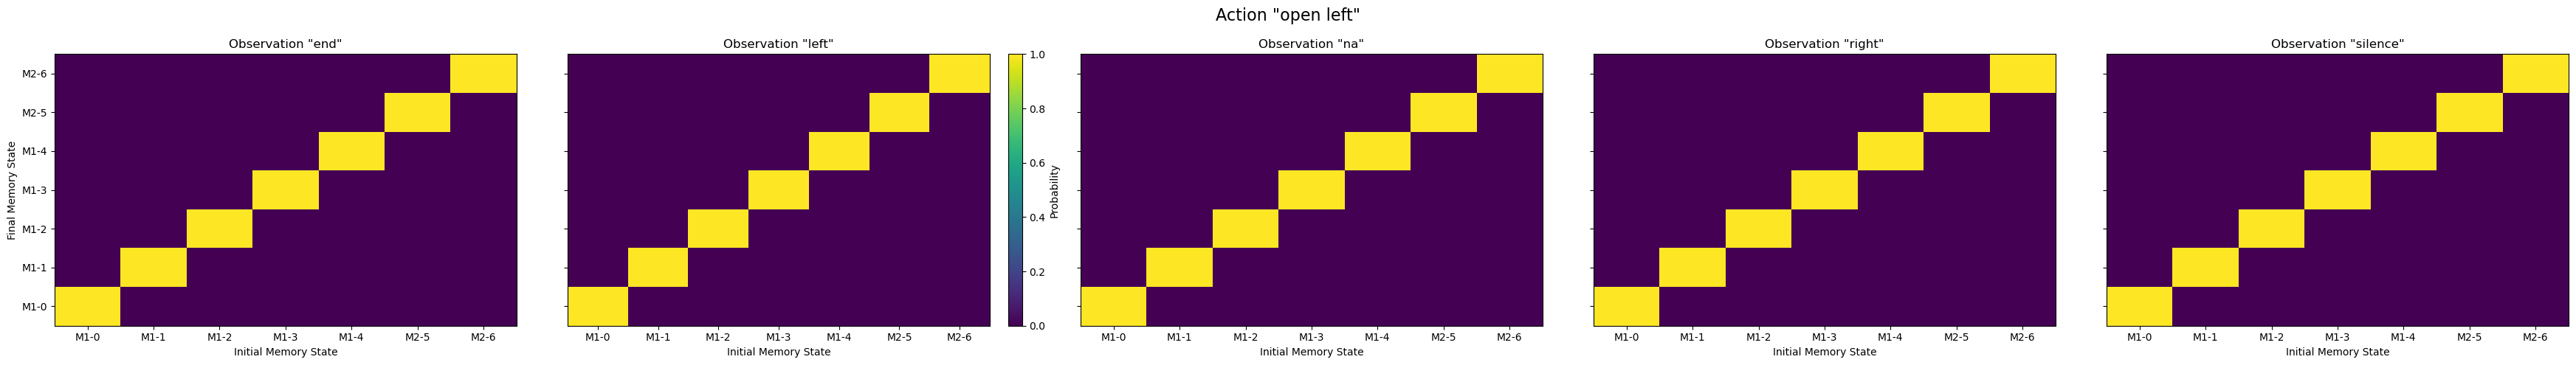

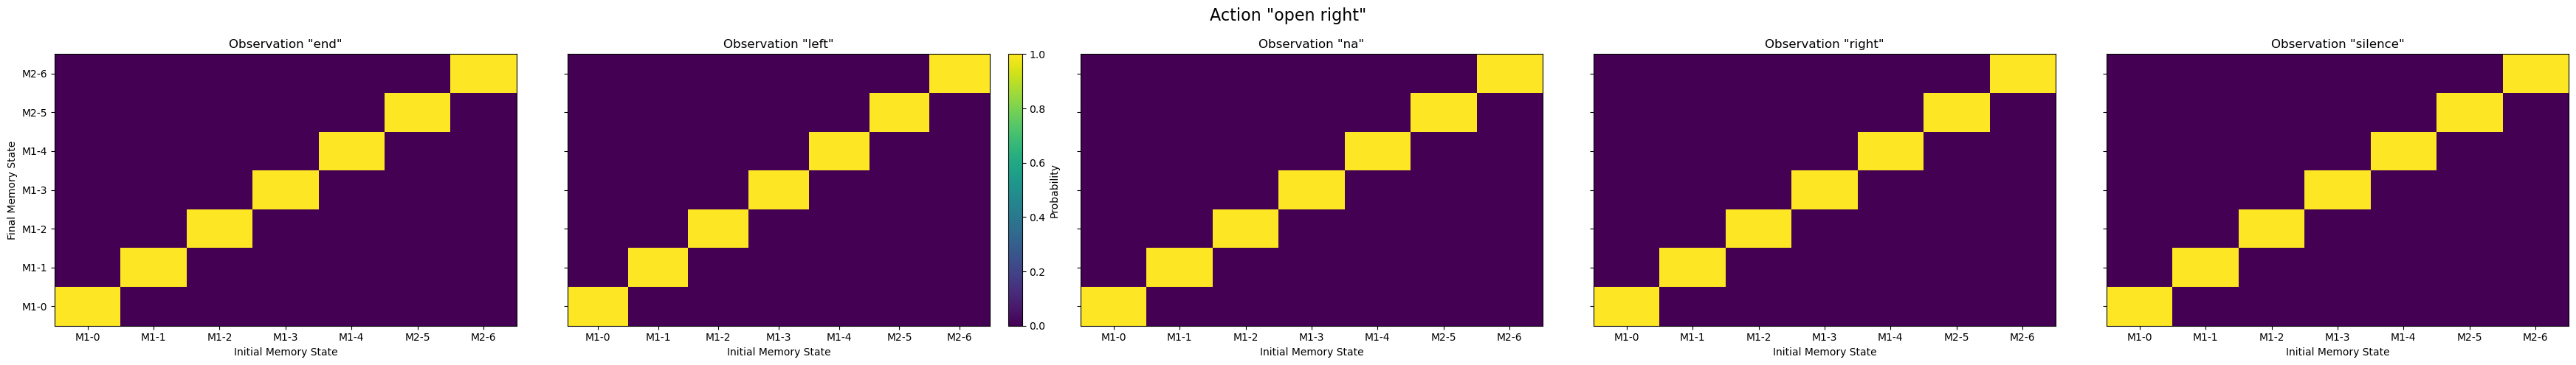

In [639]:
for idx_act in range(len(ActSpace)):
    fig, axs = plt.subplots(1, len(ObsSpace), figsize=(35, 5), sharey=True)
    for idx_obs in range(len(ObsSpace)):
        c = axs[idx_obs].pcolormesh(
            MemSpace_best,
            MemSpace_best,
            FSC_M7.get_memory_transitions()[idx_obs][idx_act].T
        )
        axs[idx_obs].set_xlabel('Initial Memory State')
        axs[idx_obs].set_title(f'Observation "{ObsSpace[idx_obs]}"')
        fig.suptitle(f'Action "{ActSpace[idx_act]}"', fontsize=16)
        if idx_obs == 0:
            axs[idx_obs].set_ylabel('Final Memory State')
        if idx_obs == 1:
            fig.colorbar(c, ax=axs[idx_obs], label='Probability', orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

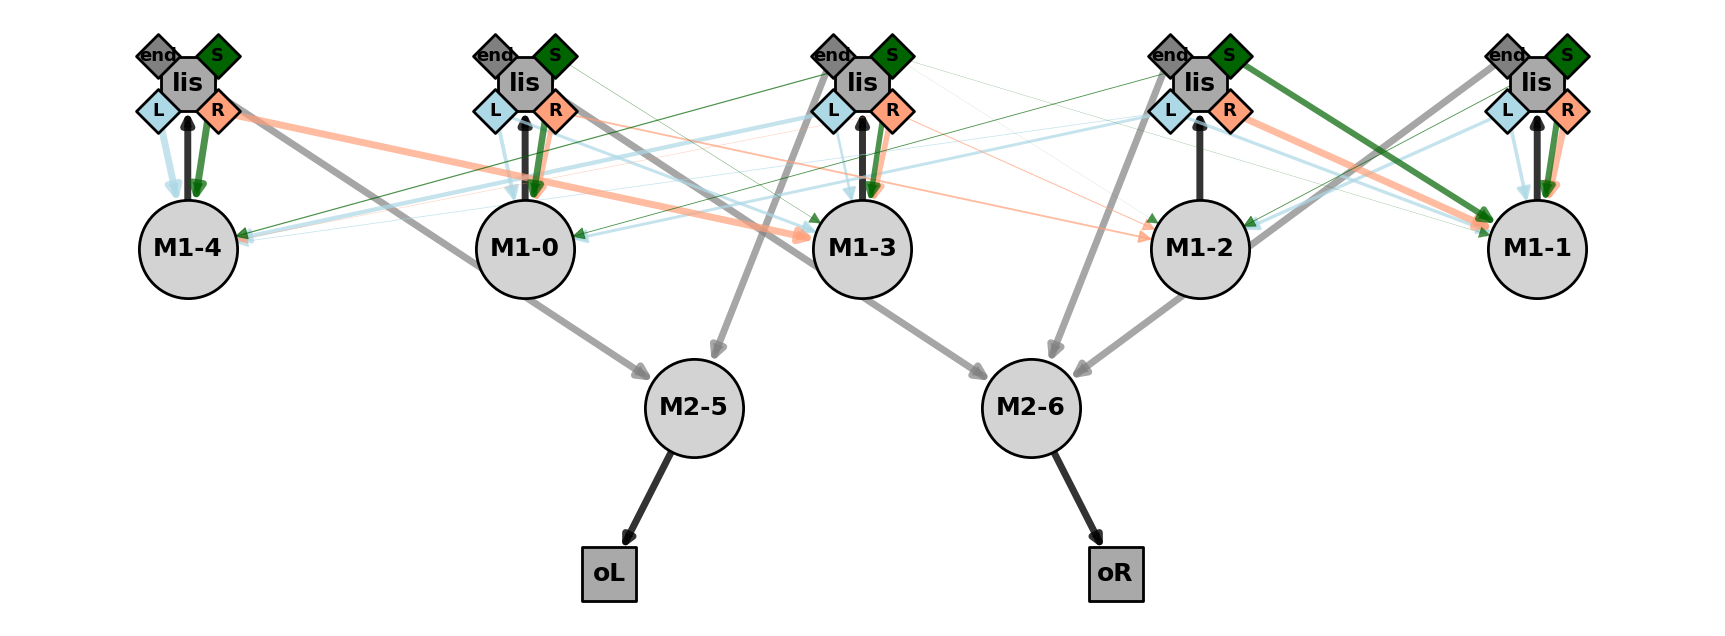

In [662]:
chain_ordering = [4, 0, 3, 2, 1, 5, 6]

fig, ax = plt.subplots(figsize=(22, 8))
FSC_M7.plot_twolayers_FSC(observation_node_colors=["gray", 'lightblue', "k", 'lightsalmon', "darkgreen"],
                               memory_ordering = chain_ordering,
                               memory_names=MemSpace_best[chain_ordering],
                               action_names=['lis', 'oL', 'oR'], observation_names=["end", 'L', "", 'R', "S"],
                               AllowedObsFromAct = AllowedObsFromAct, obs_rotation=np.pi/4 * 3,
                               ax = ax)
plt.show()

In [663]:
FSC_M7.get_memory_transitions()[idx_obs_right, idx_listen, 1], FSC_M7.get_memory_transitions()[idx_obs_left, idx_listen, 0]

(array([4.20974703e-07, 9.99999579e-01, 7.20190274e-15, 6.20987544e-18,
        7.18267873e-21, 0.00000000e+00, 0.00000000e+00]),
 array([5.58956903e-01, 5.11110368e-08, 8.85453665e-14, 4.41043046e-01,
        6.47416219e-26, 0.00000000e+00, 0.00000000e+00]))

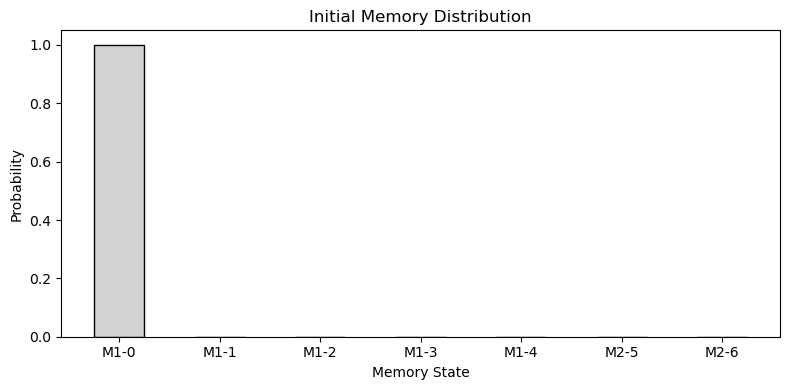

In [664]:
rho = FSC_M7.rho

# rho is the initial distribution of memory states, make an histogram of it
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(rho)), rho, color='lightgray', edgecolor='k', width=0.5)
ax.set_xlabel('Memory State')
ax.set_ylabel('Probability')
ax.set_title('Initial Memory Distribution')
ax.set_xticks(np.arange(len(MemSpace_best)), MemSpace_best)
plt.tight_layout()
plt.show()

In [665]:
generated_observations_train = []
generated_actions_train = []
generated_memories_train = []
for trjseq in generated_trajectories_train:
    for trj in trjseq:
        generated_observations_train.append(trj["observations"])
        generated_actions_train.append(trj["actions"])
        generated_memories_train.append(trj["memories"])

generated_observations_val = []
generated_actions_val = []
generated_memories_val = []
for trjseq in generated_trajectories_val:
    for trj in trjseq:
        generated_observations_val.append(trj["observations"])
        generated_actions_val.append(trj["actions"])
        generated_memories_val.append(trj["memories"])

In [666]:
num_bins = 20
bins_diff_train_gen, prob_R_train_gen, mem_occ_train_gen = compute_right_vs_obsdiff_wmem(generated_observations_train,
                                                                                         generated_actions_train,
                                                                                         generated_memories_train,
                                                                                         FSC_M7.M,
                                                                                         num_bins)
bins_diff_val_gen, prob_R_val_gen, mem_occ_val_gen = compute_right_vs_obsdiff_wmem(generated_observations_val,
                                                                                   generated_actions_val,
                                                                                   generated_memories_val,
                                                                                   FSC_M7.M,
                                                                                   num_bins)

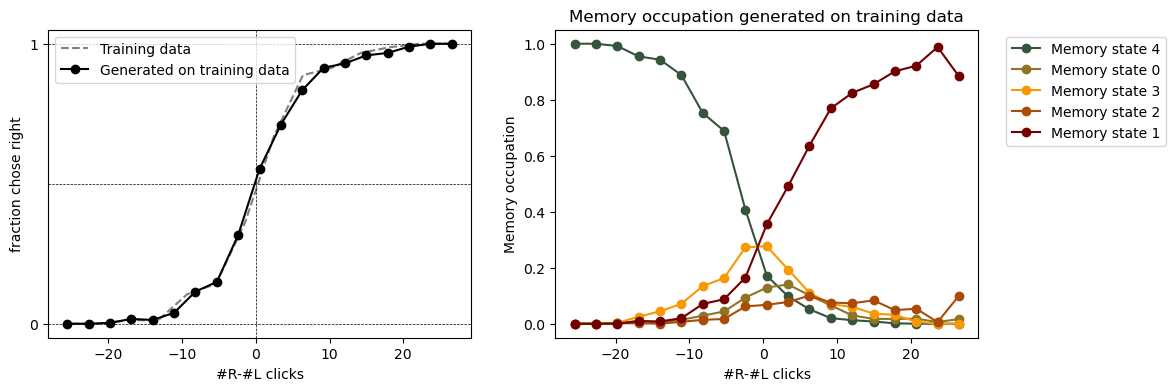

In [667]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_train, prob_R_train, ls = '--', label='Training data', c = "gray")
axs[0].plot(bins_diff_train_gen, prob_R_train_gen, '-o', label='Generated on training data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M7.M - 2]):
    color_mem = memories_cmap(idx_seq / (FSC_M7.M - 3))
    axs[1].plot(bins_diff_train_gen, mem_occ_train_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)
    
axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on training data')
plt.show()

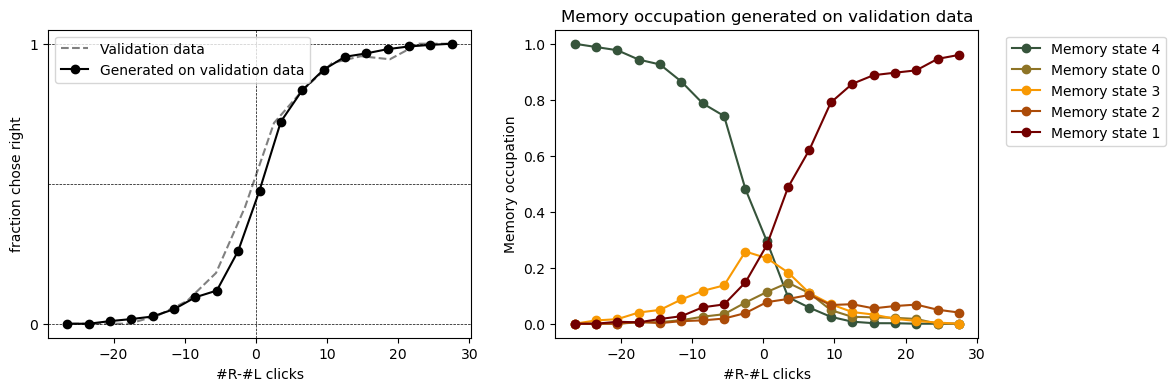

In [668]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 4))
axs[0].plot(bins_diff_val, prob_R_val, ls = '--', label='Validation data', c = "gray")
axs[0].plot(bins_diff_val_gen, prob_R_val_gen, '-o', label='Generated on validation data', c = "k")
axs[0].axhline(0.5, color='k', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].set_xlabel('#R-#L clicks')
axs[0].set_ylabel('fraction chose right')
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_yticks([0, 1])
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axs[0].axhline(1, color='k', linestyle='--', linewidth=0.5)
axs[0].legend()

for idx_seq, idx_mem in enumerate(chain_ordering[:FSC_M7.M - 2]):
    color_mem = memories_cmap(idx_seq / (FSC_M7.M - 3))
    axs[1].plot(bins_diff_val_gen, mem_occ_val_gen[:, idx_mem], '-o', label=f'Memory state {idx_mem}', color=color_mem)

axs[1].set_xlabel('#R-#L clicks')
axs[1].set_ylabel('Memory occupation')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].set_title('Memory occupation generated on validation data')
plt.show()